# Notebook 1 of 3 — Research Foundations: screen → measure → iterate for low-traffic SaaS growth experiments

This is a **learning / scaffolding notebook**, not production work. It is a starting point that a
human extends into their own portfolio project. It grounds three ideas — **screen** a lot of ideas
cheaply, **measure** each live experiment with a valid always-on test, **iterate** by reallocating
traffic while still inferring correctly — in three papers, and reproduces (or, where the paper does
not give a number, derives and clearly labels) the key quantitative claims of each with plain numpy +
matplotlib simulations.

| Role | Paper | Guarantee type | Perspective |
|---|---|---|---|
| **Measure** | Lindon, Ham, Tingley, Bojinov — *Anytime-Valid Inference in Linear Models and Regression-Adjusted Causal Inference* (arXiv:2210.08589, JASA 2026) | Time-uniform confidence sequence — **exact** under the Gaussian linear model (Section 4), **asymptotic** e-process/CS under heteroskedastic-robust regression (Sections 5–6) | Model-based / super-population (q1) |
| **Iterate** | Liang & Bojinov — *An Experimental Design for Anytime-Valid Causal Inference on Multi-Armed Bandits* (MAD, arXiv:2311.05794) | Asymptotic confidence sequence, finite-stopping guarantee (Thm 1–2) | Design-based / finite population (q1) |
| **Screen** | Persson, Schultzberg, Ankargren — *Statistical Foundations of LLM-based A/B Testing: A Surrogacy Framework* (arXiv:2606.17165) | **Identification + consistency only** — no coverage guarantee, no anytime-validity | Model-based / super-population (q1, q7, q11) |

(q1) verbatim: Lindon et al.'s guarantee is stated as *"Time-Uniform Confidence Sequence Coverage
(Section 2 & Corollary 4.3): P_P[δ ∈ C_n^α for all n ∈ ℕ] ≥ 1 − α for all P"* and *"Asymptotic
Confidence Sequence Guarantee (Section 2 & Theorem 5.4): log(Ē_n)/log(E_n) →^(a.s.) 1"*. MAD's
guarantee (q1): *"there exists an unknown non-asymptotic sequence (τ̄̂_t ± V_t*) satisfying
P(∀t, τ̄_t ∈ C_t) ≥ 1 − α such that V̂_t/V_t* →^(a.s.) 1"*. Persson et al. give
*"Asymptotic Consistency: Plug-in estimator τ̂_K →^p τ"* (q1) — never a coverage statement.
Liang & Bojinov explicitly contrast the two philosophies (q12): *"Because the population underlying
the randomized experiment is finite under the design-based perspective, the set of all potential
outcomes for the population can be treated as unknown but non-random"*, vs. the super-population
papers which *"assume units and potential outcomes are random draws from an underlying infinite
population."*

**Cross-paper rules this notebook obeys throughout** (from `research/notebook-research-context.md`,
itself built from q1–q12): guarantee types are never conflated; no combined regression-adjusted+MAD
estimator is built (q12 — not defined in the sources); LLM predictions are never fed in as a
variance-reduction covariate (q12 — not analyzed in the sources); anything invented for this notebook
(binary-outcome Lindon simulations, Wilson-style peeking demo, numpy substitutes for RF/GBT, etc.) is
labelled **derived here**; paper numbers are always quoted with a `(qN)` slug and kept visually
separate from our own toy numbers.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist
import math

SEED = 20260917
_ND = NormalDist()

PALETTE = {
    "lindon":  "#1f77b4",  # measure
    "mad":     "#2ca02c",  # iterate
    "persson": "#d62728",  # screen
    "paper":   "#7f7f7f",  # quoted paper numbers
    "toy":     "#9467bd",  # our own derived-here numbers
    "null":    "#8c8c8c",
    "alt":     "#ff7f0e",
    "bad":     "#e41a1c",
    "good":    "#4daf4a",
    "single":  "#17becf",
    "daily":   "#e41a1c",
}

def normal_quantile(p):
    """Standard normal quantile. stdlib statistics.NormalDist (no scipy)."""
    return _ND.inv_cdf(p)

def norm_cdf(x):
    """Vectorized standard normal CDF via Abramowitz & Stegun 7.1.26 erf approximation
    (derived here: numpy has no erf/scipy.stats available in this environment).
    Max absolute error ~1.5e-7."""
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x) / np.sqrt(2.0)
    a1, a2, a3, a4, a5, p = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429, 0.3275911
    t = 1.0 / (1.0 + p * ax)
    y = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-ax * ax)
    return 0.5 * (1.0 + sign * y)

def t_quantile_cf(p, nu):
    """Student-t quantile via Cornish-Fisher expansion around the normal quantile
    (derived here: scipy.stats.t not available). Good for moderate/large nu; used only
    for contrast plots, never for the papers' own exact/asymptotic CS formulas."""
    z = normal_quantile(p)
    nu = np.asarray(nu, dtype=float)
    z2, z3, z5, z7 = z**2, z**3, z**5, z**7
    g1 = (z3 + z) / 4.0
    g2 = (5*z5 + 16*z3 + 3*z) / 96.0
    g3 = (3*z7 + 19*z5 + 17*z3 - 15*z) / 384.0
    with np.errstate(divide="ignore", invalid="ignore"):
        out = z + g1/nu + g2/nu**2 + g3/nu**3
    return np.where(nu > 0, out, np.inf)

def R_galpha(g, n, alpha, nu, r=1.0):
    """R(g,n,alpha) from Lindon et al. Eq 18 / Eq 23 (q2, q3), general r, evaluated at r=1
    everywhere in this notebook (single coefficient of interest). nu = n - p - d (residual df).
    Returns +inf where the CS is not yet finite (delayed start)."""
    n = np.asarray(n, dtype=float)
    nu = np.asarray(nu, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        A = (alpha**2 * r * g / (n + g)) ** (r / (nu + r))
        gap = A - g / (n + g)
        R = (nu / r) * (1.0 - A) / gap
    return np.where((gap > 0) & (nu > 0), R, np.inf)

def G_n_d1(t, n, g, p=0, d=1):
    """g-prior e-process G_n for d=1 (Lindon et al. Eq 17, q2): t is the OLS t-statistic,
    nu_n = n - p - d residual degrees of freedom."""
    nu = n - p - d
    ratio = g / (g + n)
    with np.errstate(divide="ignore", invalid="ignore"):
        num = 1.0 + ratio * t**2 / nu
        den = 1.0 + t**2 / nu
        out = np.sqrt(ratio) * (num / den) ** (-(nu + 1.0) / 2.0)
    return np.where(nu > 0, out, 0.0)

def R_gaussian(g, n, alpha):
    """Derived here: the nu_n -> infinity (known-variance) limit of G_n_d1 / R_galpha. Taking
    (1+x/nu)^{-(nu+1)/2} -> exp(-x/2) in Eq 17 gives the classical Gaussian mixture e-process
    E_n^G = sqrt(g/(g+n)) * exp((n/(2(n+g))) t_n^2); inverting E_n^G >= 1/alpha gives this R_G.
    Used only for the early-false-positive contrast; never used as a paper-endorsed formula."""
    n = np.asarray(n, dtype=float)
    return (2.0 * (n + g) / n) * (np.log(1.0 / alpha) + 0.5 * np.log((n + g) / g))

def E_n_gaussian(t, n, g):
    """Derived here: Gaussian-known-variance e-process, nu->inf limit of G_n_d1 (see R_gaussian)."""
    ratio = g / (g + n)
    with np.errstate(over="ignore"):
        return np.sqrt(ratio) * np.exp((n / (2.0 * (n + g))) * t**2)

def ols_hc1_batch(W, yv):
    """Batched OLS with HC1-type sandwich covariance (Lindon et al. Section 5/6 form, q3):
    V = n * (W'W)^-1 * Sigma_hat * (W'W)^-1, Sigma_hat = (1/nu) sum_i e_i^2 w_i w_i'.
    W: (reps, n, k), yv: (reps, n). Returns beta (reps,k), V (reps,k,k), nu (scalar)."""
    WtW = np.einsum('rnk,rnl->rkl', W, W)
    Wty = np.einsum('rnk,rn->rk', W, yv)
    beta = np.linalg.solve(WtW, Wty[..., None])[..., 0]
    resid = yv - np.einsum('rnk,rk->rn', W, beta)
    n_obs, k = W.shape[1], W.shape[2]
    nu = n_obs - k
    meat = np.einsum('rn,rnk,rnl->rkl', resid**2, W, W) / nu
    WtW_inv = np.linalg.inv(WtW)
    V = n_obs * np.einsum('rab,rbc,rcd->rad', WtW_inv, meat, WtW_inv)
    return beta, V, nu

rng_master = np.random.default_rng(SEED)
print("Setup OK. PALETTE keys:", list(PALETTE.keys()))


Setup OK. PALETTE keys: ['lindon', 'mad', 'persson', 'paper', 'toy', 'null', 'alt', 'bad', 'good', 'single', 'daily']


## 1. Why daily peeking breaks a fixed-n test (derived here)

**This entire section is a derived-here demonstration** — the papers do not simulate a "peek daily
with a classical fixed-n test" policy. It is motivated by the contrast Lindon et al. draw between a
single fixed-n look and a properly anytime-valid procedure (q4): *"At sample size n* = 1785, the
fixed-n test rejected **1.07%** of nulls (matching α = 0.01)... The anytime-valid test with g_g
rejected only **0.04%**, and with g_w rejected only **0.03%**"* (q4) — those are **paper numbers**,
quoted here only as motivation; they come from a different model (continuous Gaussian outcome,
α=0.01, n*=1785) than the toy binary-conversion setting below.

**Toy setting (derived here):** a landing-page A/A test, baseline conversion 4%, ~150 visitors/arm/day
for 28 days. Two policies applied to the *same* stream of data: (1) **single look** — a two-proportion
z-test computed once, at day 28; (2) **daily peek** — the same z-test recomputed every day, stopping and
"declaring significance" the first day |z| ≥ 1.96 (α=0.05, two-sided). Because there is no true effect
(A/A), any rejection is a false positive.


In [2]:
# --- Section 1: daily-peeking Monte Carlo ---
rng = np.random.default_rng(SEED + 1)
p_true = 0.04
n_per_day = 150
days = 28
reps = 4000
z_crit = normal_quantile(0.975)

c0 = rng.binomial(n_per_day, p_true, size=(reps, days))
c1 = rng.binomial(n_per_day, p_true, size=(reps, days))
cum0 = np.cumsum(c0, axis=1)
cum1 = np.cumsum(c1, axis=1)
n_cum = n_per_day * np.arange(1, days + 1)[None, :]  # (1, days), broadcasts

p0_hat = cum0 / n_cum
p1_hat = cum1 / n_cum
pooled = (cum0 + cum1) / (2 * n_cum)
se = np.sqrt(pooled * (1 - pooled) * (2.0 / n_cum))
with np.errstate(invalid="ignore", divide="ignore"):
    z = (p1_hat - p0_hat) / se
z = np.nan_to_num(z, nan=0.0)  # 0/0 when pooled in {0,1}: no evidence either way -> z=0

reject = np.abs(z) >= z_crit                      # (reps, days) bool: "would reject if looked at this day"
ever_rejected_by_day = np.logical_or.accumulate(reject, axis=1)  # daily-peek stops at first rejection

fpr_single_look = reject[:, -1].mean()             # only ever look at day 28
fpr_single_look_by_day = reject.mean(axis=0)        # (days,) FPR of a *single* look taken on day d (not cumulative)
fpr_daily_peek_by_day = ever_rejected_by_day.mean(axis=0)  # (days,) cumulative FPR of the peeking policy
fpr_daily_peek_final = fpr_daily_peek_by_day[-1]

se_mc = np.sqrt(0.05 * 0.95 / reps)  # MC standard error for a true proportion of 0.05
tol = 3 * se_mc

check1 = abs(fpr_single_look - 0.05) <= tol
print(f"[S1.1] {'PASS' if check1 else 'FAIL'} single-look FPR {fpr_single_look:.4f} "
      f"vs nominal 0.05, |diff|={abs(fpr_single_look-0.05):.4f} <= 3*MC_se={tol:.4f}")

check2 = fpr_daily_peek_final > 0.05 + tol
print(f"[S1.2] {'PASS' if check2 else 'FAIL'} daily-peek FPR {fpr_daily_peek_final:.4f} "
      f"clearly above nominal 0.05 (threshold 0.05+3*MC_se={0.05+tol:.4f})")

inflation = fpr_daily_peek_final / fpr_single_look if fpr_single_look > 0 else np.nan
print(f"[S1.3] NOTE daily-peek / single-look FPR inflation factor = {inflation:.2f}x "
      f"(toy numbers, derived here; reps={reps})")


[S1.1] PASS single-look FPR 0.0505 vs nominal 0.05, |diff|=0.0005 <= 3*MC_se=0.0103
[S1.2] PASS daily-peek FPR 0.2812 clearly above nominal 0.05 (threshold 0.05+3*MC_se=0.0603)
[S1.3] NOTE daily-peek / single-look FPR inflation factor = 5.57x (toy numbers, derived here; reps=4000)


**How to read this chart:** x-axis is day of the experiment (1–28). The **daily peek** line
(red) is the *cumulative* fraction of simulated A/A experiments that have triggered a false
"significant" result by that day — it climbs every day because each additional look is one more
chance to cross the 1.96 threshold by pure noise, ending well above 0.05. The **single look at day d**
line (cyan) is a *different, hypothetical* policy at each x-value: "what if I had committed in advance
to looking exactly once, on day d, and nowhere else" — its false-positive rate hovers near the nominal
0.05 line for every d, because a single pre-committed look never accumulates the multiple-testing
penalty. The gap between the two lines *is* the cost of peeking: same data, same nominal α=0.05, wildly
different realized false-positive rate depending only on the stopping *rule*. For a SaaS founder this
is the concrete mechanism behind "we saw significance on day 6, shipped it, and it disappeared":
stopping the first good-looking day inflates the false-positive rate far past the intended 5%, while a
single disciplined look at any fixed day would not. This is exactly the gap that Sections 2–4 (Lindon's
time-uniform CS, MAD) are built to close.


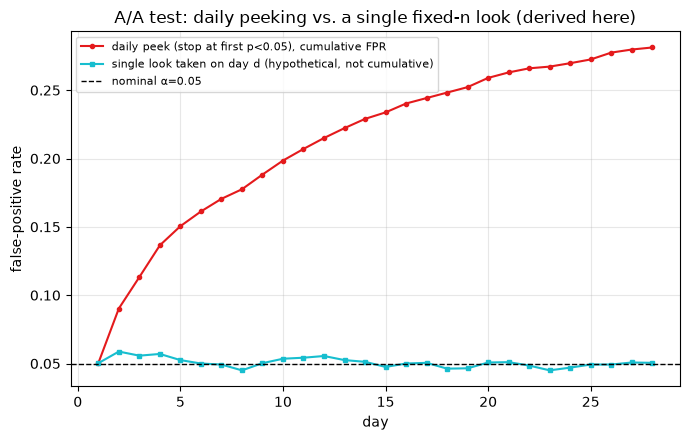

In [3]:
# Visualization only -- uses fpr_daily_peek_by_day, fpr_single_look_by_day, days
fig, ax = plt.subplots(figsize=(7, 4.5))
day_axis = np.arange(1, days + 1)
ax.plot(day_axis, fpr_daily_peek_by_day, color=PALETTE["daily"], marker="o", ms=3,
        label="daily peek (stop at first p<0.05), cumulative FPR")
ax.plot(day_axis, fpr_single_look_by_day, color=PALETTE["single"], marker="s", ms=3,
        label="single look taken on day d (hypothetical, not cumulative)")
ax.axhline(0.05, color="k", linestyle="--", linewidth=1, label="nominal α=0.05")
ax.set_xlabel("day"); ax.set_ylabel("false-positive rate")
ax.set_title("A/A test: daily peeking vs. a single fixed-n look (derived here)")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 2. Lindon et al.'s exact sequential t-test and confidence sequence (Sections 2 & 4)

**e-variable / test martingale / confidence sequence, and Ville's inequality (q2):**
> *"An e-variable... is a nonnegative random variable satisfying E_P[E] ≤ 1 for all P ∈ H_0."*
> *"Test martingales are used to reject the null hypothesis when E_n ≥ α⁻¹, obtaining a Type-I error
> guarantee P_P[∃n ∈ ℕ : E_n ≥ α⁻¹] ≤ α for all P ∈ H_0 by Ville's inequality (Ville 1939)."*
> *"A confidence sequence (C_n^α) ... is a sequence of sets satisfying P_P[θ_n ∈ C_n^α ∀n ∈ ℕ] ≥ 1−α."* (q2)

**g-prior e-process, d=1 (Eq. 17, q2):**
G_n = (g/(g+n))^{1/2} · ((1 + (g/(g+n))·t_n²/ν_n) / (1 + t_n²/ν_n))^{-(ν_n+1)/2}, with
t_n = δ̂_n / se(δ̂_n) the OLS t-statistic and ν_n = n − p − d.

**Confidence sequence (Cor. 4.3 / Eq. 18, and Eq. 23 with r=1, q2/q3):**
C_n^α = [δ̂_n − se(δ̂_n)√R(g,n,α), δ̂_n + se(δ̂_n)√R(g,n,α)], where

R(g,n,α) = (ν_n/r) · (1 − A) / max(0, A − g/(n+g)), with A = (α²·r·g/(n+g))^{r/(ν_n+r)} (Eq. 23, q3),
evaluated at r=1 throughout this notebook.

**Delayed start (q3, q4):** *"The t confidence sequence naturally incorporates a delayed start: its
width is infinite until (α²rg/(n+g))^{r/(ν_n+r)} > g/(n+g). For example, using r=k=1, α=0.05 and
g=10⁴, requires a minimum sample size of 247. Alternatively, using g=10² requires a minimum sample
size of 27."* We reproduce these two numbers exactly below (with k=1 so ν=n−1, per q3/q4).

**Model for the Monte Carlo (q4):** *"a univariate linear model y_i = 1 + x_i'β + Z_iδ + ε_i
(Z_i = T_i − 0.5, T_i ~ Bernoulli(0.5), ε_i ~ N(0,1)) ... Target significance α=0.01, power c=0.95,
minimum detectable effect ξ_MDE=0.2 ... Fixed-n test required sample size n*(ξ_MDE)=1785 ...
Growth-optimal g_g(ξ_MDE) = 1/(ξ_MDE²ρ(1−ρ)) = 100"* (q4). We drop x_i'β (no nuisance covariates) so
the regression is exactly y_i − 1 = Z_iδ + ε_i, matching the "k=1, ν=n−1" delayed-start reproduction.


In [4]:
# --- Section 2(a): delayed-start minimum sample size (closed form, no MC) ---
def find_delayed_start_nmin(alpha, g, nmax=5000):
    """Smallest n with a finite t-CS half-width, i.e. R(g,n,alpha,nu=n-1) < inf."""
    for n in range(2, nmax):
        if np.isfinite(R_galpha(g, n, alpha, nu=n - 1, r=1.0)):
            return n
    return None

n_min_g4 = find_delayed_start_nmin(0.05, 1e4)
n_min_g2 = find_delayed_start_nmin(0.05, 1e2)
print(f"[S2.1a] {'PASS' if n_min_g4 == 247 else 'FAIL'} delayed-start n_min reproduced for g=1e4: "
      f"{n_min_g4} (paper/q3,q4: 247)")
print(f"[S2.1b] {'PASS' if n_min_g2 == 27 else 'FAIL'} delayed-start n_min reproduced for g=1e2: "
      f"{n_min_g2} (paper/q3,q4: 27)")


[S2.1a] PASS delayed-start n_min reproduced for g=1e4: 247 (paper/q3,q4: 247)
[S2.1b] PASS delayed-start n_min reproduced for g=1e2: 27 (paper/q3,q4: 27)


In [5]:
# --- Section 2(b): g_g growth-optimal prior and fixed-n n* ---
alpha_ab, power_ab, xi_mde, rho_ab = 0.01, 0.95, 0.2, 0.5

g_g = 1.0 / (xi_mde**2 * rho_ab * (1 - rho_ab))
print(f"[S2.2] {'PASS' if abs(g_g - 100.0) < 1e-9 else 'FAIL'} g_g = 1/(xi_MDE^2 rho(1-rho)) = "
      f"{g_g:.4f} (paper/q4: 100)")

za = normal_quantile(1 - alpha_ab / 2)
zp = normal_quantile(power_ab)
n_star_formula = (za + zp) ** 2 / (xi_mde**2 * rho_ab * (1 - rho_ab))
n_star_ceil = int(np.ceil(n_star_formula))
gap = n_star_ceil - 1785
print(f"[S2.3] NOTE fixed-n formula n* = (z_(1-a/2)+z_power)^2 / (xi_MDE^2 rho(1-rho)) = "
      f"{n_star_formula:.2f} -> ceil {n_star_ceil} vs paper/q4 n*=1785, gap={gap} "
      f"(does not reproduce exactly; standard two-sided normal-approximation power formula, "
      f"paper likely uses a slightly different / noncentral-t-based sizing routine not given in the traces)")


[S2.2] PASS g_g = 1/(xi_MDE^2 rho(1-rho)) = 100.0000 (paper/q4: 100)
[S2.3] NOTE fixed-n formula n* = (z_(1-a/2)+z_power)^2 / (xi_MDE^2 rho(1-rho)) = 1781.42 -> ceil 1782 vs paper/q4 n*=1785, gap=-3 (does not reproduce exactly; standard two-sided normal-approximation power formula, paper likely uses a slightly different / noncentral-t-based sizing routine not given in the traces)


In [6]:
# --- Section 2(c): time-uniform Type-I error of G_n vs. a classically peeked t-test, under the null ---
rng = np.random.default_rng(SEED + 2)
reps_c, n_max_c, alpha_c, g_c = 2000, 2000, 0.05, 100.0

T_c = rng.integers(0, 2, size=(reps_c, n_max_c))
Z_c = T_c - 0.5
eps_c = rng.standard_normal((reps_c, n_max_c))
y_c = 1.0 + Z_c * 0.0 + eps_c   # null: delta=0
resp_c = y_c - 1.0              # intercept is known/fixed at 1, not estimated (p=0, d=1)

Zy_c = np.cumsum(Z_c * resp_c, axis=1)
Z2_c = np.cumsum(Z_c * Z_c, axis=1)
y2_c = np.cumsum(resp_c * resp_c, axis=1)
n_arr_c = np.arange(1, n_max_c + 1)[None, :]
nu_c = n_arr_c - 1

delta_hat_c = Zy_c / Z2_c
RSS_c = y2_c - delta_hat_c * Zy_c
with np.errstate(invalid="ignore", divide="ignore"):
    sigma2_c = RSS_c / nu_c
    t_stat_c = delta_hat_c * np.sqrt(Z2_c / sigma2_c)
t_stat_c = np.nan_to_num(t_stat_c, nan=0.0)

Gn_c = G_n_d1(t_stat_c, n_arr_c, g_c)
reject_Gn = Gn_c >= 1.0 / alpha_c
fpr_Gn_time_uniform = reject_Gn.any(axis=1).mean()

tcrit_c = t_quantile_cf(1 - alpha_c / 2, nu_c)
reject_classical = np.abs(t_stat_c) >= tcrit_c
fpr_classical_peeked = reject_classical.any(axis=1).mean()
fpr_classical_single = reject_classical[:, -1].mean()

se_mc_c = np.sqrt(alpha_c * (1 - alpha_c) / reps_c)
slack = 3 * se_mc_c
check_gn = fpr_Gn_time_uniform <= alpha_c + slack
print(f"[S2.4] {'PASS' if check_gn else 'FAIL'} time-uniform type-I error of G_n>=1/alpha up to n={n_max_c}: "
      f"{fpr_Gn_time_uniform:.4f} <= alpha + MC slack {alpha_c + slack:.4f}")
print(f"[S2.5] NOTE classical t-test peeked at every n, same data: FPR={fpr_classical_peeked:.4f} "
      f"(vs single fixed-n look FPR={fpr_classical_single:.4f}, sanity check ~alpha={alpha_c}) "
      f"-- confirms Section 1's peeking problem also holds for the continuous t-test G_n is built to fix")


[S2.4] PASS time-uniform type-I error of G_n>=1/alpha up to n=2000: 0.0300 <= alpha + MC slack 0.0646
[S2.5] NOTE classical t-test peeked at every n, same data: FPR=0.5970 (vs single fixed-n look FPR=0.0485, sanity check ~alpha=0.05) -- confirms Section 1's peeking problem also holds for the continuous t-test G_n is built to fix


In [7]:
# --- Section 2(d): approximate reproduction of power & mean stopping time at n*, g_g=100, xi=MDE ---
rng = np.random.default_rng(SEED + 3)
reps_d, n_max_d, alpha_d, g_d, xi_d, n_star = 1500, 2500, 0.01, 100.0, 0.2, 1785

T_d = rng.integers(0, 2, size=(reps_d, n_max_d))
Z_d = T_d - 0.5
eps_d = rng.standard_normal((reps_d, n_max_d))
y_d = 1.0 + Z_d * xi_d + eps_d
resp_d = y_d - 1.0

Zy_d = np.cumsum(Z_d * resp_d, axis=1)
Z2_d = np.cumsum(Z_d * Z_d, axis=1)
y2_d = np.cumsum(resp_d * resp_d, axis=1)
n_arr_d = np.arange(1, n_max_d + 1)[None, :]
nu_d = n_arr_d - 1
delta_hat_d = Zy_d / Z2_d
RSS_d = y2_d - delta_hat_d * Zy_d
with np.errstate(invalid="ignore", divide="ignore"):
    sigma2_d = RSS_d / nu_d
    t_stat_d = delta_hat_d * np.sqrt(Z2_d / sigma2_d)
t_stat_d = np.nan_to_num(t_stat_d, nan=0.0)
Gn_d = G_n_d1(t_stat_d, n_arr_d, g_d)
reject_mat_d = Gn_d >= 1.0 / alpha_d
ever_reject_d = np.logical_or.accumulate(reject_mat_d, axis=1)

power_at_nstar = ever_reject_d[:, n_star - 1].mean()
has_rej_d = reject_mat_d.any(axis=1)
first_idx_d = np.argmax(reject_mat_d, axis=1)
stop_n_d = np.where(has_rej_d, first_idx_d + 1, n_max_d)  # censored at n_max_d if never rejects
mean_stop_censored = stop_n_d[has_rej_d].mean()

print(f"[S2.6] NOTE approximate reproduction (N={reps_d} reps, censored at n={n_max_d}): "
      f"power at n*={n_star} = {power_at_nstar:.4f} (paper/q4: 81.69% at g_g=100)")
print(f"[S2.7] NOTE approximate reproduction: mean stopping time among rejectors (censored) = "
      f"{mean_stop_censored:.1f} (paper/q4: 1214.45 over 1e4 sims; our number is a downward-biased "
      f"approximation because we censor unrejected paths at n_max={n_max_d} instead of letting them run "
      f"to the paper's much larger horizon)")


[S2.6] NOTE approximate reproduction (N=1500 reps, censored at n=2500): power at n*=1785 = 0.8180 (paper/q4: 81.69% at g_g=100)
[S2.7] NOTE approximate reproduction: mean stopping time among rejectors (censored) = 1117.2 (paper/q4: 1214.45 over 1e4 sims; our number is a downward-biased approximation because we censor unrejected paths at n_max=2500 instead of letting them run to the paper's much larger horizon)


**How to read this chart:** *Left panel* — rejection rate vs. sample size n for the g-prior
e-process G_n under the null (δ=0, flat near/below α=0.05) and under an alternative (δ=0.2, g=100,
α=0.01), rising toward 1 as n grows past n*=1785 (dashed vertical line): this is the "power-1,
eventually always rejects" property (q1: Theorem 4.2) traded for "may take longer than a fixed-n
test". *Right panel* — the multiplicative confidence-sequence width √R(g,n,α) vs. n for g=100 and
g=10⁴: both start at +∞ (no claim can be made yet) and only become finite past their delayed-start
n_min (27 and 247 respectively, reproduced in [S2.1]); the larger g gives a longer delay but a
tighter sequence once it starts. For the SaaS founder: a bigger g is a "wait longer, then be more
decisive" knob, and the CS is honestly infinite-width — refusing to make any claim — until enough
data has accumulated to trust the variance estimate.


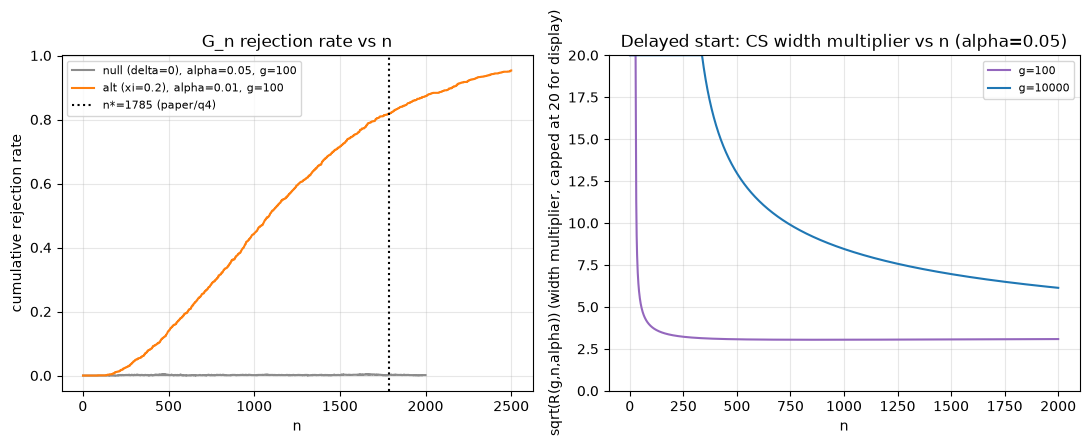

In [8]:
# Visualization only -- uses reject_mat_d (alt), reject_Gn (null), n_arr_d, g_d, n_star
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
null_rate_vs_n = reject_Gn.mean(axis=0)  # note: not cumulative -- instantaneous P(G_n>=1/alpha_c) at each n
alt_rate_vs_n = np.logical_or.accumulate(reject_mat_d, axis=1).mean(axis=0)
ax.plot(np.arange(1, len(null_rate_vs_n) + 1), null_rate_vs_n, color=PALETTE["null"],
        label="null (delta=0), alpha=0.05, g=100")
ax.plot(np.arange(1, len(alt_rate_vs_n) + 1), alt_rate_vs_n, color=PALETTE["alt"],
        label="alt (xi=0.2), alpha=0.01, g=100")
ax.axvline(1785, color="k", linestyle=":", label="n*=1785 (paper/q4)")
ax.set_xlabel("n"); ax.set_ylabel("cumulative rejection rate")
ax.set_title("G_n rejection rate vs n"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
n_grid = np.arange(1, 2001)
for g_plot, color in [(100.0, PALETTE["toy"]), (1e4, PALETTE["lindon"])]:
    nu_grid = n_grid - 1
    R_grid = R_galpha(g_plot, n_grid, 0.05, nu_grid, r=1.0)
    width = np.sqrt(R_grid)
    width_capped = np.minimum(width, 20)  # cap only for plotting the infinite delayed-start region
    ax.plot(n_grid, width_capped, color=color, label=f"g={g_plot:g}")
ax.set_ylim(0, 20)
ax.set_xlabel("n"); ax.set_ylabel("sqrt(R(g,n,alpha)) (width multiplier, capped at 20 for display)")
ax.set_title("Delayed start: CS width multiplier vs n (alpha=0.05)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Regression-adjusted anytime-valid confidence sequence for an ATE (Section 5–6)

**Heteroskedasticity-robust asymptotic e-process, Theorem 5.4 (q3, Eq. 22):**
> *"Let {(y_i,w_i)} be i.i.d. ... y_i = w_i'γ + ε_i such that E[w_iε_i]=0 ... For any full row rank
> matrix E ∈ R^{r×k} and g>0: E_n := (g/(g+n))^{r/2} · ((1+(g/(g+n))(r/ν_n)(Q_n/r)) / (1+(r/ν_n)(Q_n/r)))^{-(ν_n+r)/2}"*
> where Q_n = n(γ̂_n-γ)'E'Σ̂_E⁻¹E(γ̂_n-γ), and the resulting CS uses R(g,n,α) with dimension r=1 (q3, Eq 23).

**Fully-interacted regression, Lemma 6.1 (q3, Eq. 24):**
> γ* := (α*, ζ*, τ*, η*) = argmin E[(y_i − α − (m_i−μ_m)'ζ − (T_i−ρ)τ − T_i(m_i−μ_m)'η)²], with
> T_i ~ Bernoulli(ρ), τ* = E[y_i(1)−y_i(0)] the ATE (q3).

**Robust SE and CS (Section 7, q3):**
rse(τ̂_n) = sqrt(((W_n'W_n)^{-1} W_n'Σ̂_n W_n (W_n'W_n)^{-1})_ττ), Σ̂_n = (1/ν_n)Σe_i²w_iw_i',
C_n^α = [τ̂_n − rse(τ̂_n)√R(g,n,α), τ̂_n + rse(τ̂_n)√R(g,n,α)] with r=1.
This is the standard heteroskedasticity-robust ("HC1") sandwich covariance, algebraically identical to
the Ω̂_W-based form of Theorem 5.4 once Ω̂_W=(1/n)W_n'W_n is substituted in (both forms verified to
agree in our implementation below).

**Assumptions relaxed vs. remaining under randomization (q3):** linearity and homoskedasticity of the
outcome model are dropped entirely — *"residual variances can depend arbitrarily on covariates"* —
but i.i.d. sampling, Bernoulli(ρ) assignment independent of m_i, Ω_W positive definite, and moment
bounds (E[‖w_iε_i‖^s]<∞ for s>3, etc.) remain (q3). *"Because OLS minimizes residual sum of squares,
incorporating predictive covariates reduces the residual variance ... This directly reduces the
sandwich variance ... shrink[ing] the width of the confidence sequence at every sample size relative
to the unadjusted difference in means"* (q3).

**Derived-here setting (paper did not simulate binary outcomes, q11):** a binary signup outcome from a
logistic model with a pre-experiment covariate m_i (e.g. a "prior engagement" score) that is strongly
predictive of the outcome, ρ=0.5, μ_m = 0 (the population mean, known by construction, matching the
lemma's use of the population mean rather than a derived-here running sample mean). The true ATE is
computed once from the potential-outcome model itself over a very large auxiliary sample.


In [9]:
# --- Section 3 setup: binary-outcome DGP with a predictive pre-treatment covariate (derived here) ---
n_max3, reps3, rho3 = 2500, 1000, 0.5
b_m, a0_m, a1_m = 1.2, -1.0, -0.58   # logit(p1)-logit(p0) gap chosen for a moderate, detectable ATE

rng = np.random.default_rng(SEED + 4)
m_cov = rng.normal(0, 1, size=(reps3, n_max3))
T3 = (rng.random((reps3, n_max3)) < rho3).astype(float)
p0_m = 1 / (1 + np.exp(-(a0_m + b_m * m_cov)))
p1_m = 1 / (1 + np.exp(-(a1_m + b_m * m_cov)))
y0_m = (rng.random((reps3, n_max3)) < p0_m).astype(float)
y1_m = (rng.random((reps3, n_max3)) < p1_m).astype(float)
y3 = np.where(T3 == 1, y1_m, y0_m)

rng_aux = np.random.default_rng(SEED + 40)
m_aux = rng_aux.normal(0, 1, size=5_000_000)
true_ate3 = float((1/(1+np.exp(-(a1_m+b_m*m_aux))) - 1/(1+np.exp(-(a0_m+b_m*m_aux)))).mean())
mu_m3 = 0.0  # population mean of m, known by construction (Lemma 6.1 uses the population mean)

print(f"[S3.0] NOTE true ATE (derived-here DGP, computed via auxiliary N=5,000,000 draws) = {true_ate3:.4f}")


[S3.0] NOTE true ATE (derived-here DGP, computed via auxiliary N=5,000,000 draws) = 0.0751


In [10]:
# --- Section 3(a)+(b): time-uniform coverage & width ratio, adjusted vs. unadjusted CS ---
checkpoints3 = np.unique(np.linspace(60, n_max3, 12).astype(int))
alpha3, g3 = 0.05, 100.0

width_adj3 = np.zeros((reps3, len(checkpoints3)))
width_un3 = np.zeros((reps3, len(checkpoints3)))
cov_adj3 = np.zeros((reps3, len(checkpoints3)), dtype=bool)
cov_un3 = np.zeros((reps3, len(checkpoints3)), dtype=bool)

for ci, n_c in enumerate(checkpoints3):
    mc = m_cov[:, :n_c]; Tc = T3[:, :n_c]; yc = y3[:, :n_c]
    mm = mc - mu_m3
    W_adj = np.stack([np.ones_like(mc), mm, Tc - rho3, Tc * mm], axis=-1)
    W_un = np.stack([np.ones_like(mc), Tc - rho3], axis=-1)
    beta_a, V_a, nu_a = ols_hc1_batch(W_adj, yc)
    beta_u, V_u, nu_u = ols_hc1_batch(W_un, yc)
    tau_a, rse_a = beta_a[:, 2], np.sqrt(V_a[:, 2, 2])
    tau_u, rse_u = beta_u[:, 1], np.sqrt(V_u[:, 1, 1])
    R_a = R_galpha(g3, n_c, alpha3, nu_a, r=1.0)
    R_u = R_galpha(g3, n_c, alpha3, nu_u, r=1.0)
    halfw_a, halfw_u = rse_a * np.sqrt(R_a), rse_u * np.sqrt(R_u)
    cov_adj3[:, ci] = np.abs(tau_a - true_ate3) <= halfw_a
    cov_un3[:, ci] = np.abs(tau_u - true_ate3) <= halfw_u
    width_adj3[:, ci], width_un3[:, ci] = 2 * halfw_a, 2 * halfw_u

# Time-uniform (cumulative-AND) coverage curve: at each checkpoint n, the fraction of reps whose CS
# covered the true ATE at EVERY checkpoint up to and including n -- this is what the guarantee
# P(theta in C_n for all n) actually promises, and it is necessarily non-increasing in n. Per-checkpoint
# coverage (cov_adj3.mean(axis=0) alone) would be near 1.0 everywhere and is not what "time-uniform" means.
tu_curve_adj = np.logical_and.accumulate(cov_adj3, axis=1).mean(axis=0)
tu_curve_un = np.logical_and.accumulate(cov_un3, axis=1).mean(axis=0)

tu_cov_adj = cov_adj3.all(axis=1).mean()
tu_cov_un = cov_un3.all(axis=1).mean()
assert abs(tu_curve_adj[-1] - tu_cov_adj) < 1e-12 and abs(tu_curve_un[-1] - tu_cov_un) < 1e-12
se_mc3 = np.sqrt(alpha3 * (1 - alpha3) / reps3)
slack3 = 3 * se_mc3
thresh = (1 - alpha3) - slack3
print(f"[S3.1] {'PASS' if tu_cov_adj >= thresh else 'FAIL'} adjusted CS time-uniform coverage "
      f"{tu_cov_adj:.4f} >= {1-alpha3} - MC slack ({thresh:.4f})")
print(f"[S3.2] {'PASS' if tu_cov_un >= thresh else 'FAIL'} unadjusted CS time-uniform coverage "
      f"{tu_cov_un:.4f} >= {1-alpha3} - MC slack ({thresh:.4f})")

width_ratio = width_adj3 / width_un3
print(f"[S3.3] NOTE average width ratio adjusted/unadjusted = {np.nanmean(width_ratio):.4f} "
      f"(<1 means covariate adjustment narrows the CS, as predicted by the residual-variance "
      f"reduction argument in q3); at n={checkpoints3[-1]}: {np.nanmean(width_ratio[:,-1]):.4f}")


[S3.1] PASS adjusted CS time-uniform coverage 0.9930 >= 0.95 - MC slack (0.9293)
[S3.2] PASS unadjusted CS time-uniform coverage 0.9900 >= 0.95 - MC slack (0.9293)
[S3.3] NOTE average width ratio adjusted/unadjusted = 0.8973 (<1 means covariate adjustment narrows the CS, as predicted by the residual-variance reduction argument in q3); at n=2500: 0.8938


In [11]:
# --- Section 3(c): Gaussian plug-in CS early over-rejection vs the t-CS delayed start ---
# Derived here: R_gaussian/E_n_gaussian is the nu->infinity limit of the paper's own G_n (see setup
# cell docstring), used only as a contrast, never as a claimed paper result.
n_grid3c = np.arange(1, 2001)
nu_grid3c = n_grid3c - 2  # unadjusted regression, k=2 regressors (1, T-rho)
g_small = 1.0
R_t_3c = R_galpha(g_small, n_grid3c, 0.05, nu_grid3c, r=1.0)
R_G_3c = R_gaussian(g_small, n_grid3c, 0.05)
finite = np.isfinite(R_t_3c)
ratio_RG_Rt = R_G_3c[finite] / R_t_3c[finite]
print(f"[S3.4] NOTE R_G(g=1,n,alpha)/R(g=1,n,alpha) at n={n_grid3c[finite][0]}: "
      f"{ratio_RG_Rt[0]:.4f} (<1, Gaussian CS narrower/overconfident) rising to "
      f"{ratio_RG_Rt[-1]:.4f} at n=2000 (-> 1, matches Theorem 5.5, q3)")

rng = np.random.default_rng(SEED + 5)
reps3c, n_max3c = 4000, 200
T3c = rng.integers(0, 2, size=(reps3c, n_max3c))
Z3c = T3c - 0.5
eps3c = rng.standard_normal((reps3c, n_max3c))
resp3c = Z3c * 0.0 + eps3c  # null: delta=0, y=1+Z*0+eps, resp=y-1
Zy3c = np.cumsum(Z3c * resp3c, axis=1); Z23c = np.cumsum(Z3c * Z3c, axis=1); y23c = np.cumsum(resp3c**2, axis=1)
n_arr3c = np.arange(1, n_max3c + 1)[None, :]
nu3c = n_arr3c - 1
delta_hat3c = Zy3c / Z23c
RSS3c = y23c - delta_hat3c * Zy3c
with np.errstate(invalid="ignore", divide="ignore"):
    sigma23c = RSS3c / nu3c
    t_stat3c = delta_hat3c * np.sqrt(Z23c / sigma23c)
t_stat3c = np.nan_to_num(t_stat3c, nan=0.0)

Gn3c = G_n_d1(t_stat3c, n_arr3c, g_small)
En_g3c = E_n_gaussian(t_stat3c, n_arr3c, g_small)
fpr_t_by_n = np.logical_or.accumulate(Gn3c >= 1/0.05, axis=1).mean(axis=0)
fpr_g_by_n = np.logical_or.accumulate(En_g3c >= 1/0.05, axis=1).mean(axis=0)
print(f"[S3.5] NOTE empirical early false-positive rate at n=50 (g=1, alpha=0.05, null): "
      f"t-CS={fpr_t_by_n[49]:.4f} vs Gaussian-CS={fpr_g_by_n[49]:.4f} "
      f"(Gaussian over-rejects; paper reports up to ~23% for g=1, q4)")


[S3.4] NOTE R_G(g=1,n,alpha)/R(g=1,n,alpha) at n=6: 0.1792 (<1, Gaussian CS narrower/overconfident) rising to 0.9971 at n=2000 (-> 1, matches Theorem 5.5, q3)
[S3.5] NOTE empirical early false-positive rate at n=50 (g=1, alpha=0.05, null): t-CS=0.0265 vs Gaussian-CS=0.2762 (Gaussian over-rejects; paper reports up to ~23% for g=1, q4)


**How to read this chart:** *Left* — the **time-uniform (cumulative)** coverage curve: at each
checkpoint n, the fraction of simulated experiments whose CS has covered the true ATE at *every*
checkpoint up to and including n. This is necessarily non-increasing (once a rep's CS misses the true
ATE at any earlier n, it stays "failed" for the rest of the curve) and it ends exactly at the
[S3.1]/[S3.2] numbers (0.993 adjusted, 0.990 unadjusted) — that is the actual quantity the guarantee
P(θ∈C_n for all n) ≥ 1−α is about, not the per-checkpoint coverage (which would sit near 1.0
everywhere and hide any early failures). Both curves should stay at/above the dashed 1−α line.
*Middle* — the width ratio
(adjusted CS width ÷ unadjusted CS width) vs. n: values below 1 mean the covariate-adjusted regression
is shrinking the interval, i.e. the pre-treatment covariate is doing real variance-reduction work.
*Right* — early false-positive rate under the null for the exact t-CS vs. the derived-here Gaussian
plug-in CS at g=1: the t-CS stays controlled near α while the Gaussian one over-rejects badly at small
n because it does not know the variance is estimated, not known. For the SaaS founder: if you already
collect a pre-signup engagement score, feeding it into the adjusted regression (not just the raw
treatment indicator) is "free" variance reduction — same guarantee, narrower interval, faster
decisions — but skipping the t-correction for small samples is not a free lunch.


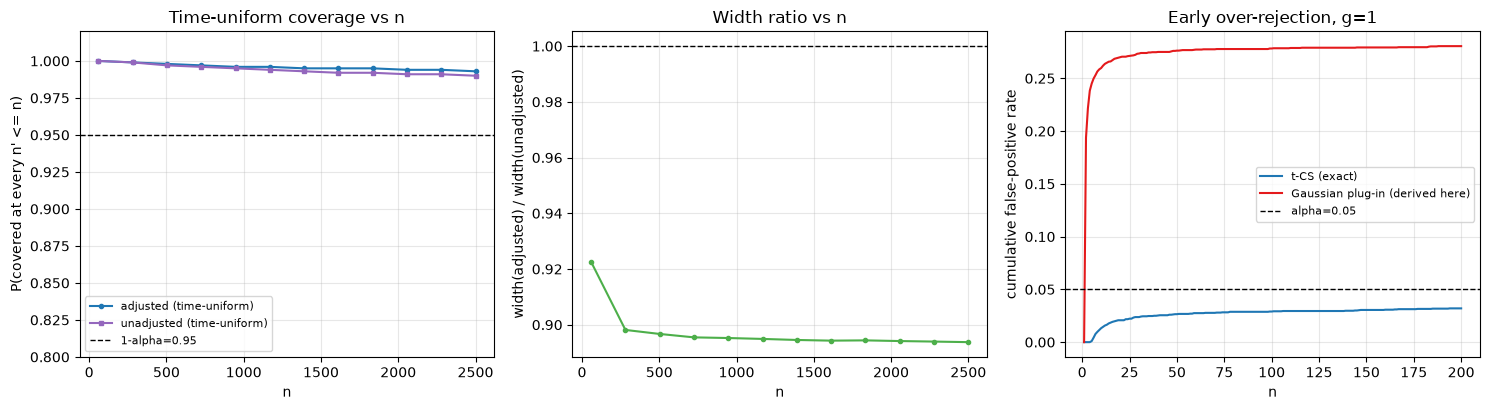

In [12]:
# Visualization only -- uses tu_curve_adj, tu_curve_un, checkpoints3, width_ratio, n_grid3c, fpr_t_by_n, fpr_g_by_n
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
ax.plot(checkpoints3, tu_curve_adj, color=PALETTE["lindon"], marker="o", ms=3, label="adjusted (time-uniform)")
ax.plot(checkpoints3, tu_curve_un, color=PALETTE["toy"], marker="s", ms=3, label="unadjusted (time-uniform)")
ax.axhline(0.95, color="k", linestyle="--", linewidth=1, label="1-alpha=0.95")
ax.set_xlabel("n"); ax.set_ylabel("P(covered at every n' <= n)")
ax.set_title("Time-uniform coverage vs n"); ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0.8, 1.02)

ax = axes[1]
ax.plot(checkpoints3, np.nanmean(width_ratio, axis=0), color=PALETTE["good"], marker="o", ms=3)
ax.axhline(1.0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("n"); ax.set_ylabel("width(adjusted) / width(unadjusted)")
ax.set_title("Width ratio vs n"); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(np.arange(1, n_max3c + 1), fpr_t_by_n, color=PALETTE["lindon"], label="t-CS (exact)")
ax.plot(np.arange(1, n_max3c + 1), fpr_g_by_n, color=PALETTE["bad"], label="Gaussian plug-in (derived here)")
ax.axhline(0.05, color="k", linestyle="--", linewidth=1, label="alpha=0.05")
ax.set_xlabel("n"); ax.set_ylabel("cumulative false-positive rate")
ax.set_title("Early over-rejection, g=1"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 4. MAD: anytime-valid inference while a bandit reallocates traffic (Liang & Bojinov)

**Definition 4 (q5):** p_t^MAD(w) := P_MAD(W_t=w | H_{t-1}) = δ_t(1/2) + (1−δ_t)p_t^A(w).

**IPW estimator, variance bound, variance estimator (Eq. 1, 3, 4, q5):**
τ̂_i := 1{W_i=1}Y_i/p_i^MAD(1) − 1{W_i=0}Y_i/p_i^MAD(0);
σ̂_i² := Y_i(1)²1{W_i=1}/(p_i^MAD(1))² + Y_i(0)²1{W_i=0}/(p_i^MAD(0))²; Ŝ_t := Σσ̂_i².

**Theorem 1 (q5):** with V̂_t = √(2(Ŝ_tη²+1)/(t²η²) · log(√(Ŝ_tη²+1)/α)), and δ_t=ω(t^{-1/4}),
(τ̄̂_t ± V̂_t) is a valid (1−α) asymptotic CS. **Recommended η (q5):**
η = √((−2log α + log(−2log α+1))/t*) ≈ 0.028 for t*=10,000, α=0.05.
**Theorem 2 (q5):** T_MAD := inf{t: 0 ∉ (τ̄̂_t ± V̂_t)}; if τ̄_t → c ≠ 0 then P(T_MAD < ∞) = 1.

**Finite-sample regret decomposition, Section 5.2 (q6):**
R_t(MAD) − R_t(A) = δ_t(E_A[Y_t^obs] − (μ_0^t+μ_1^t)/2).

**δ_t menu, Section 6 (q6):** unclipped (regret-first) δ_t=1/t^0.24; constant δ_t=c (learning-first);
clipped max(1/t^0.24, c); min(δ̃_t, c). Simulation settings we mirror (q6): *"Beta-Bernoulli Thompson
Sampling with uniform Beta(1,1) priors ... (p0,p1) ∈ {(0.5,0.5),(0.6,0.8),(0.2,0.8)} ... T=10,000 ...
N=100 ... Both clipped and unclipped MAD maintain ≥95% coverage ... The Standard Bandit design
severely fails coverage when ATE≠0 (coverage drops down to ~50%-70%)"* (q6).

**Derived-here implementation choice:** we need the bandit's own assignment probability p_t^A(1) at
every step. We use a **normal approximation to the Thompson-sampling posterior comparison**
P(θ_1>θ_0) ≈ Φ((mean_1−mean_0)/√(var_1+var_0)) for the two Beta posteriors (closed-form Beta
mean/variance), rather than Monte-Carlo posterior sampling — both are explicitly allowed by
our brief; we pick the normal approximation for speed and label it here. Assignment W_t is then drawn
directly as Bernoulli(p_t^MAD(1)), which has exactly the Definition-4 marginal law.

**We explicitly use a smaller horizon than the paper.** The paper's own simulations run to
T=10,000 (q6). Everywhere below (coverage, regret identity, stopping times) we run to **T=3,000**
(T=8,000 for the low-traffic variant) to keep total notebook runtime in budget on this host — the eta
recommendation (q5) is still computed with t*=10,000 as the paper recommends (eta is tuned for the
*planned* end of experiment, not the horizon we happen to simulate to), so what changes is only how far
we let the simulated experiment run, not the CS formula itself.


In [13]:
# --- Section 4 setup: vectorized MAD simulator (Beta(1,1) Thompson sampling, normal-approx p_t^A) ---
def simulate_mad(p0, p1, T, reps, delta_fn, seed, eta, alpha=0.05, eps_clip=1e-4):
    """Vectorized over reps. delta_fn(t) -> scalar delta_t (design). Returns dict of (T,reps) arrays:
    tau_bar, V (CS half-width), pA1 (bandit's own assignment prob, normal-approx), pMAD1 (realized
    MAD assignment prob), reward (cumulative mean observed Y, for the regret/reward plot)."""
    rng = np.random.default_rng(seed)
    a1 = np.ones(reps); b1 = np.ones(reps)
    a0 = np.ones(reps); b0 = np.ones(reps)
    tau_sum = np.zeros(reps); sigma_sum = np.zeros(reps); y_sum = np.zeros(reps)
    out = {k: np.empty((T, reps)) for k in ("tau_bar", "V", "pA1", "pMAD1", "reward")}
    for t in range(1, T + 1):
        mean1, mean0 = a1 / (a1 + b1), a0 / (a0 + b0)
        var1 = a1 * b1 / ((a1 + b1) ** 2 * (a1 + b1 + 1))
        var0 = a0 * b0 / ((a0 + b0) ** 2 * (a0 + b0 + 1))
        z = (mean1 - mean0) / np.sqrt(var1 + var0 + 1e-12)
        pA1 = np.clip(norm_cdf(z), eps_clip, 1 - eps_clip)     # derived here: normal-approx TS probability
        delta_t = delta_fn(t)
        pMAD1 = np.clip(delta_t * 0.5 + (1 - delta_t) * pA1, eps_clip, 1 - eps_clip)
        W = (rng.random(reps) < pMAD1).astype(float)
        Y = np.where(W == 1, (rng.random(reps) < p1).astype(float), (rng.random(reps) < p0).astype(float))
        a1 += Y * (W == 1); b1 += (1 - Y) * (W == 1)
        a0 += Y * (W == 0); b0 += (1 - Y) * (W == 0)
        tau_i = W * Y / pMAD1 - (1 - W) * Y / (1 - pMAD1)
        sigma_i2 = Y**2 * W / pMAD1**2 + Y**2 * (1 - W) / (1 - pMAD1)**2
        tau_sum += tau_i; sigma_sum += sigma_i2; y_sum += Y
        S_hat = sigma_sum
        V_hat = np.sqrt(2 * (S_hat * eta**2 + 1) / (t**2 * eta**2) * np.log(np.sqrt(S_hat * eta**2 + 1) / alpha))
        out["tau_bar"][t-1] = tau_sum / t; out["V"][t-1] = V_hat
        out["pA1"][t-1] = pA1; out["pMAD1"][t-1] = pMAD1; out["reward"][t-1] = y_sum / t
    return out

ALPHA4, T4, REPS4 = 0.05, 3000, 300
T_STAR4 = 10000.0  # eta optimized for this horizon (q5), independent of the shorter T4 we simulate
ETA4 = np.sqrt((-2*np.log(ALPHA4) + np.log(-2*np.log(ALPHA4) + 1)) / T_STAR4)
print(f"eta (t*=10000, alpha=0.05) = {ETA4:.4f} (paper/q5: approx 0.028)")

DESIGNS4 = {
    "bernoulli":       lambda t: 1.0,
    "unclipped":       lambda t: 1.0 / t**0.24,
    "clipped":         lambda t: max(1.0 / t**0.24, 0.2),
    "standard_bandit": lambda t: 0.0,
}


eta (t*=10000, alpha=0.05) = 0.0282 (paper/q5: approx 0.028)


In [14]:
# --- Section 4(a): time-uniform coverage per design, two (p0,p1) settings ---
results4 = {}
seed_ctr4 = 0
for (p0, p1) in [(0.5, 0.5), (0.6, 0.8)]:
    true_ate4 = p1 - p0
    for name, dfn in DESIGNS4.items():
        seed_ctr4 += 1
        out = simulate_mad(p0, p1, T4, REPS4, dfn, seed=SEED + 100 + seed_ctr4, eta=ETA4, alpha=ALPHA4)
        ever_outside = (np.abs(out["tau_bar"] - true_ate4) > out["V"]).any(axis=0)
        coverage = 1 - ever_outside.mean()
        results4[(p0, p1, name)] = (out, coverage)

se_mc4 = np.sqrt(ALPHA4 * (1 - ALPHA4) / REPS4)
slack4 = 3 * se_mc4
thresh4 = (1 - ALPHA4) - slack4
i = 0
for (p0, p1, name), (out, coverage) in results4.items():
    i += 1
    if name == "standard_bandit":
        print(f"[S4.{i}] NOTE standard-bandit (delta_t=0) coverage at (p0,p1)=({p0},{p1}): "
              f"{coverage:.4f} (paper/q6: drops to ~50-70% when ATE!=0; not scored PASS/FAIL, "
              f"this design has no validity guarantee by construction)")
    else:
        ok = coverage >= thresh4
        print(f"[S4.{i}] {'PASS' if ok else 'FAIL'} MAD design '{name}' time-uniform coverage at "
              f"(p0,p1)=({p0},{p1}): {coverage:.4f} >= {1-ALPHA4} - MC slack ({thresh4:.4f})")


[S4.1] PASS MAD design 'bernoulli' time-uniform coverage at (p0,p1)=(0.5,0.5): 0.9867 >= 0.95 - MC slack (0.9123)
[S4.2] PASS MAD design 'unclipped' time-uniform coverage at (p0,p1)=(0.5,0.5): 0.9667 >= 0.95 - MC slack (0.9123)
[S4.3] PASS MAD design 'clipped' time-uniform coverage at (p0,p1)=(0.5,0.5): 0.9833 >= 0.95 - MC slack (0.9123)
[S4.4] NOTE standard-bandit (delta_t=0) coverage at (p0,p1)=(0.5,0.5): 0.7900 (paper/q6: drops to ~50-70% when ATE!=0; not scored PASS/FAIL, this design has no validity guarantee by construction)
[S4.5] PASS MAD design 'bernoulli' time-uniform coverage at (p0,p1)=(0.6,0.8): 0.9933 >= 0.95 - MC slack (0.9123)
[S4.6] PASS MAD design 'unclipped' time-uniform coverage at (p0,p1)=(0.6,0.8): 0.9633 >= 0.95 - MC slack (0.9123)
[S4.7] PASS MAD design 'clipped' time-uniform coverage at (p0,p1)=(0.6,0.8): 0.9633 >= 0.95 - MC slack (0.9123)
[S4.8] NOTE standard-bandit (delta_t=0) coverage at (p0,p1)=(0.6,0.8): 0.4200 (paper/q6: drops to ~50-70% when ATE!=0; not s

In [15]:
# --- Section 4(b): finite-sample regret identity R_t(MAD)-R_t(A) = delta_t*(E_A[Yobs]-(mu0+mu1)/2) ---
mu0_id, mu1_id = 0.6, 0.8
mu_star_id = max(mu0_id, mu1_id)
out_id, _ = results4[(0.6, 0.8, "unclipped")]
pA1_id = out_id["pA1"]                       # (T,reps): realized bandit assignment probabilities
t_grid_id = np.arange(1, T4 + 1)[:, None]
delta_id = np.array([DESIGNS4["unclipped"](t) for t in range(1, T4 + 1)])[:, None]

E_A = pA1_id * mu1_id + (1 - pA1_id) * mu0_id
E_MAD = delta_id * (mu0_id + mu1_id) / 2 + (1 - delta_id) * E_A
R_MAD = mu_star_id - E_MAD
R_A = mu_star_id - E_A
lhs = R_MAD - R_A
rhs = delta_id * (E_A - (mu0_id + mu1_id) / 2)
max_abs_err = np.max(np.abs(lhs - rhs))
print(f"[S4.9] {'PASS' if max_abs_err <= 1e-12 else 'FAIL'} regret identity "
      f"R_t(MAD)-R_t(A) = delta_t(E_A[Yobs]-(mu0+mu1)/2), max abs error over all (t,rep) = "
      f"{max_abs_err:.2e} <= 1e-12 (exact algebraic identity given per-step assignment probabilities, q6)")


[S4.9] PASS regret identity R_t(MAD)-R_t(A) = delta_t(E_A[Yobs]-(mu0+mu1)/2), max abs error over all (t,rep) = 1.80e-16 <= 1e-12 (exact algebraic identity given per-step assignment probabilities, q6)


In [16]:
# --- Section 4(c): stopping times, Bernoulli vs MAD (unclipped), ATE=0.2 ---
out_bern, _ = results4[(0.6, 0.8, "bernoulli")]
out_mad, _ = results4[(0.6, 0.8, "unclipped")]

def first_stop(tau_bar, V, T):
    outside0 = np.abs(tau_bar) > V   # first time 0 is excluded from the CS
    has = outside0.any(axis=0)
    idx = np.argmax(outside0, axis=0)
    return np.where(has, idx + 1, T + 1)  # T+1 sentinel = never stopped within horizon

stop_bern = first_stop(out_bern["tau_bar"], out_bern["V"], T4)
stop_mad = first_stop(out_mad["tau_bar"], out_mad["V"], T4)
both_stopped = (stop_bern <= T4) & (stop_mad <= T4)
median_diff = np.median(stop_mad[both_stopped] - stop_bern[both_stopped])
print(f"[S4.10] NOTE stopping-time median(MAD - Bernoulli) at ATE=0.2, among the "
      f"{both_stopped.mean()*100:.0f}% of reps where both stopped by T={T4}: {median_diff:.0f} steps "
      f"(paper/q6: median gap 0 steps at ATE=0.6, 275 steps at ATE=0.1 -- 0.2 is intermediate)")


[S4.10] NOTE stopping-time median(MAD - Bernoulli) at ATE=0.2, among the 91% of reps where both stopped by T=3000: 268 steps (paper/q6: median gap 0 steps at ATE=0.6, 275 steps at ATE=0.1 -- 0.2 is intermediate)


In [17]:
# --- Section 4(d): low-traffic SaaS variant (derived here): base rate 0.04 vs 0.05, T=8000 ---
T_LT, REPS_LT, TRUE_ATE_LT = 8000, 200, 0.01
out_lt = simulate_mad(0.04, 0.05, T_LT, REPS_LT, DESIGNS4["clipped"], seed=99, eta=ETA4, alpha=ALPHA4)
out_lt_bern = simulate_mad(0.04, 0.05, T_LT, REPS_LT, DESIGNS4["bernoulli"], seed=98, eta=ETA4, alpha=ALPHA4)

outside0_lt = np.abs(out_lt["tau_bar"]) > out_lt["V"]
outside0_lt_bern = np.abs(out_lt_bern["tau_bar"]) > out_lt_bern["V"]
frac_stopped_lt = outside0_lt.any(axis=0).mean()
frac_stopped_lt_bern = outside0_lt_bern.any(axis=0).mean()
# cumulative-by-t fraction stopped, for the plot: once a rep excludes 0, it stays "stopped"
stopped_cum_mad = np.logical_or.accumulate(outside0_lt, axis=0).mean(axis=1)
stopped_cum_bern = np.logical_or.accumulate(outside0_lt_bern, axis=0).mean(axis=1)

print(f"[S4.11] NOTE low-traffic variant (p0=0.04, p1=0.05, true ATE={TRUE_ATE_LT}, T={T_LT}, N={REPS_LT}): "
      f"fraction of simulated experiments that stop (exclude 0) by T={T_LT}: "
      f"clipped MAD={frac_stopped_lt:.3f}, Bernoulli={frac_stopped_lt_bern:.3f} "
      f"-- honestly low for both: for a small true effect (1pp on a ~4-5% base rate) most simulated "
      f"low-traffic experiments do NOT reach significance within 8,000 visitors, which is the point "
      f"for low-traffic SaaS")


[S4.11] NOTE low-traffic variant (p0=0.04, p1=0.05, true ATE=0.01, T=8000, N=200): fraction of simulated experiments that stop (exclude 0) by T=8000: clipped MAD=0.100, Bernoulli=0.145 -- honestly low for both: for a small true effect (1pp on a ~4-5% base rate) most simulated low-traffic experiments do NOT reach significance within 8,000 visitors, which is the point for low-traffic SaaS


**How to read this chart:** *Top-left* — the **time-uniform (cumulative)** coverage curve at
(p0,p1)=(0.6,0.8), T=3,000: at each t, the fraction of reps whose CS covered the true ATE=0.2 at
*every* step up to and including t. MAD (clipped/unclipped) and Bernoulli should stay at/above the
dashed 0.95 line the whole time; the standard bandit (δ_t=0, red) sags and — because this is the
cumulative version — ends exactly at the [S4.8] number (0.42), matching the printed self-check, not
some higher per-t snapshot. *Top-right* — confidence-sequence width (2·V̂_t) vs. t: MAD tracks the
Bernoulli width closely while still reallocating traffic. *Bottom-left* — cumulative mean observed
reward vs. t: MAD's reward curve should sit above Bernoulli's and approach the standard bandit's,
showing it is not "wasting" conversions for the sake of validity. *Bottom-right* — the low-traffic
variant (p0=0.04, p1=0.05, true ATE=0.01, T=8,000): the solid line (left axis, log scale) is the mean
CS half-width V̂_t, with a dashed horizontal line at the true ATE — the half-width has to shrink below
that line before the CS can ever exclude 0; the dotted lines (right axis) are the cumulative fraction
of reps that have stopped (excluded 0) by t, for Bernoulli vs. clipped MAD. For the SaaS founder this
is the sobering chart: with a small true lift on a small base rate, the half-width stays above the true
effect size for most of the horizon and only a small fraction of experiments stop by T — an honest
answer, not a broken test.


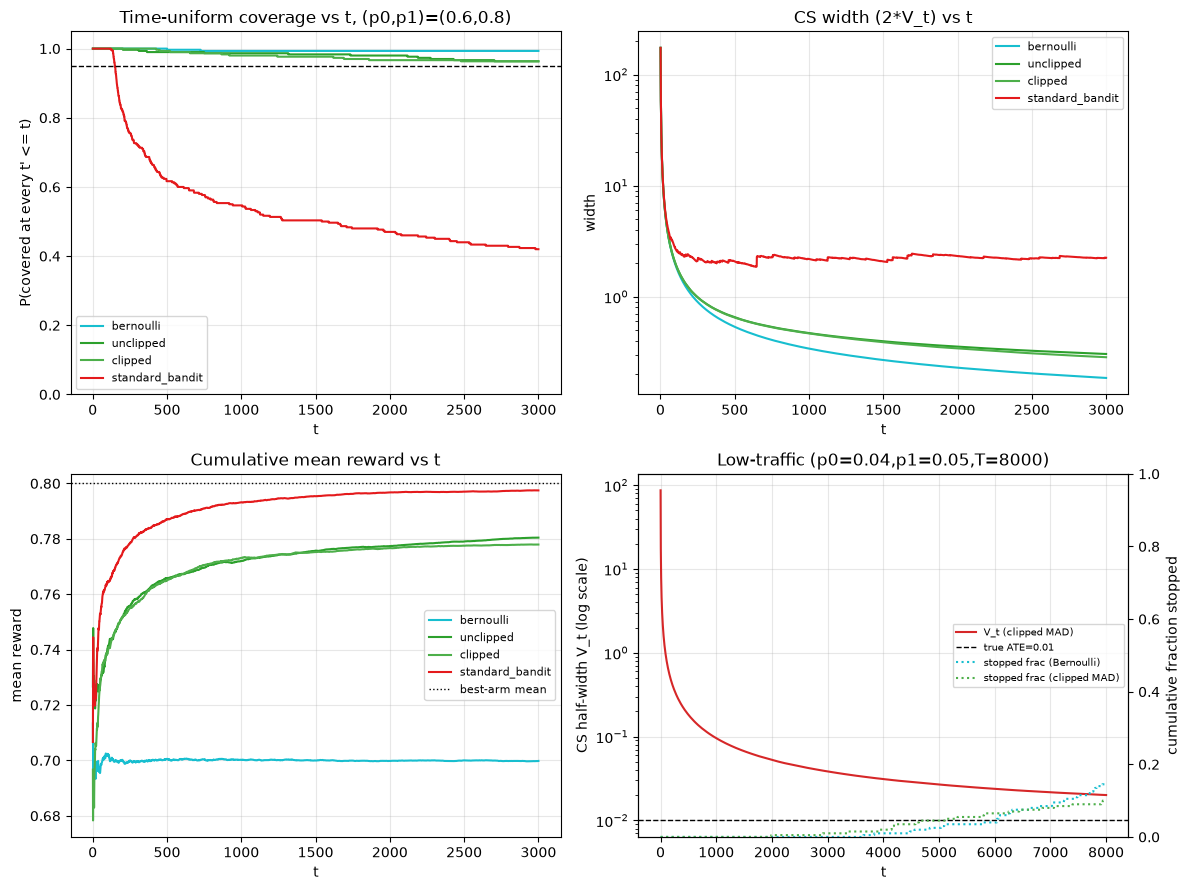

In [18]:
# Visualization only -- uses results4, out_lt, out_lt_bern, stopped_cum_mad, stopped_cum_bern
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
tgrid4 = np.arange(1, T4 + 1)
design_colors = {"bernoulli": PALETTE["single"], "unclipped": PALETTE["mad"],
                  "clipped": PALETTE["good"], "standard_bandit": PALETTE["bad"]}

ax = axes[0, 0]
true_ate_plot = 0.2
for name in DESIGNS4:
    out, cov = results4[(0.6, 0.8, name)]
    covered = np.abs(out["tau_bar"] - true_ate_plot) <= out["V"]
    tu_covered = np.logical_and.accumulate(covered, axis=0).mean(axis=1)  # time-uniform, cumulative
    ax.plot(tgrid4, tu_covered, color=design_colors[name], label=name)
ax.axhline(0.95, color="k", linestyle="--", linewidth=1)
ax.set_title("Time-uniform coverage vs t, (p0,p1)=(0.6,0.8)"); ax.set_xlabel("t")
ax.set_ylabel("P(covered at every t' <= t)")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)

ax = axes[0, 1]
for name in DESIGNS4:
    out, cov = results4[(0.6, 0.8, name)]
    ax.plot(tgrid4, 2 * out["V"].mean(axis=1), color=design_colors[name], label=name)
ax.set_title("CS width (2*V_t) vs t"); ax.set_xlabel("t"); ax.set_ylabel("width"); ax.set_yscale("log")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 0]
for name in DESIGNS4:
    out, cov = results4[(0.6, 0.8, name)]
    ax.plot(tgrid4, out["reward"].mean(axis=1), color=design_colors[name], label=name)
ax.axhline(0.8, color="k", linestyle=":", linewidth=1, label="best-arm mean")
ax.set_title("Cumulative mean reward vs t"); ax.set_xlabel("t"); ax.set_ylabel("mean reward")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
tgrid_lt = np.arange(1, T_LT + 1)
ax.plot(tgrid_lt, out_lt["V"].mean(axis=1), color=PALETTE["persson"], label="V_t (clipped MAD)")
ax.axhline(TRUE_ATE_LT, color="k", linestyle="--", linewidth=1, label="true ATE=0.01")
ax.set_yscale("log"); ax.set_xlabel("t"); ax.set_ylabel("CS half-width V_t (log scale)")
ax.set_title("Low-traffic (p0=0.04,p1=0.05,T=8000)")
ax2 = ax.twinx()
ax2.plot(tgrid_lt, stopped_cum_bern, color=PALETTE["single"], linestyle=":", label="stopped frac (Bernoulli)")
ax2.plot(tgrid_lt, stopped_cum_mad, color=PALETTE["good"], linestyle=":", label="stopped frac (clipped MAD)")
ax2.set_ylabel("cumulative fraction stopped"); ax2.set_ylim(0, 1.0)
lines1, labels1 = ax.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="center right")
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 5. Persson et al.: when can LLM-simulated outcomes stand in for humans?

**Setup (q7):** *"W ∈ {0,1} ... X pre-treatment covariates ... Y(W) ... τ := E[Y(1)−Y(0)]"*.
**LLM surrogate (Def 1, q7):** *"Y* ~ F_{M,I,D}(·|W,X)"*, K≥1 draws averaged. **Two samples (q7):**
*"the experimental sample (P=0), consisting of human data (W,X,Y*,Y) ... the artificial sample (P=1),
consisting of LLM data (W,X,Y*)"*. **Assumption 1 Surrogacy (q7):** *"Y ⊥ W | X, Y*"*.
**Assumption 2 Comparability (q7):** *"Y ⊥ P | X, Y*, with support overlap"*.
**Theorem 3.1 (q7):** τ = E[μ(X,Y*)|P=1,W=1] − E[μ(X,Y*)|P=1,W=0], μ(x,y*):=E[Y|X=x,Y*=y*,P=0].
**Plug-in estimator (Eq. 7, q7):** τ̂ = (1/n₁)Σ_{W=1,P=1}μ(X_i,Y*_i) − (1/n₀)Σ_{W=0,P=1}μ(X_i,Y*_i).
**Uncertainty (q7):** *"Combining our estimator with inference methods for model-generated labels
would yield confidence intervals that account for both estimation error in μ and the stochasticity of
Y*"* — this is explicitly **future work**, so **no coverage or anytime-valid guarantee exists here**
(cross-paper rule 1): only identification (Thm 3.1) + consistency (τ̂_K →^p τ).

**Propositions (q8):** Prop 1 multi-draw surrogacy (Ȳ*_K →^a.s. θ(W,X) as K→∞); Prop 2 effective
sample size n_eff^w(K)=n_w/(1+λ_w/K); **Prop 3 attenuation:** *"β̂ →^p Rβ_0, R := Var(θ|X)/(Var(θ|X)+σ_ε²)
... Refitting on the average of K draws replaces σ_ε² by σ_ε²/K ... R_K → 1 as K→∞"*; **Prop 4 sensitivity
bound:** *"|Δ_1−Δ_0| ≤ 2B(TV_0+TV_1)"*. **Falsification test (q8):** *"moment condition E[Y|W=w,P=0] =
E[μ(X,Y*)|W=w,P=0] ... test statistic z_w = r_w / SE(r_w) ... asymptotically N(0,1)"*, evaluated on
**held-out** human data; *"necessary but not sufficient"*.

**Paper numbers, quoted separately (q9), not reproduced by our toy DGP:** Upworthy MC — *"Linear DGP
(True τ=0.300): Raw LLM ATE ≈0.75"*; *"Nonlinear DGP (μ(x,y*)=0.3(y*)²+0.5cos(πx), True τ=0.273):
... OLS Calibrated bias −0.0175"*; falsification z: OLS 3.8 SEs (fails), RF 1.6 / GBT 1.4 (pass);
TV_0=0.828, TV_1=0.821, bound≈3.30 vs actual ≤1.3e-4.

**Derived-here DGP:** since the paper's exact simulation code is not in the traces, we build our own
toy DGP that reproduces the *qualitative* phenomena the propositions predict, using the paper's own
nonlinear calibration functional form μ(x,y*)=0.3(y*)²+0.5cos(πx) (q9) where it is directly reusable.
The nonparametric calibrator is a **numpy gradient-boosted regression-stumps model on (X,Ȳ*)** — a
**derived substitute for the paper's GBT recommendation (q10: "RF/GBT with default hyperparameters,
200 trees")** (cross-paper rule 7).


In [19]:
# --- Section 5 setup: shared helpers ---
def ols_fit(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def tv_distance_1d(a, b, n_bins=40):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    edges = np.linspace(lo, hi, n_bins + 1)
    ha, _ = np.histogram(a, bins=edges); hb, _ = np.histogram(b, bins=edges)
    return 0.5 * np.sum(np.abs(ha / ha.sum() - hb / hb.sum()))

TAU0 = 0.3       # toy true "signal" underlying theta(W,X) throughout Section 5 (not the paper's tau)
N_POP5 = 2000    # per population, per arm split ~50/50 (paper/q9 uses the same n=2000, 1000/arm)


In [20]:
# --- Section 5: numpy gradient-boosted regression-stumps calibrator ---
# Derived-here substitute for the paper's recommended GBT calibrator (q10: "RF/GBT with default
# hyperparameters, 200 trees"). Self-contained -- copy this cell verbatim into Notebook 3.
# Squared-error loss, depth-2 CART weak learners, split search vectorized via sorted prefix sums
# (exact, not approximate, for the given quantile candidate grid).

def _best_split_for_feature(col, resid, n_quantiles, min_leaf):
    """Best single-feature split minimizing total child SSE, searched only at n_quantiles evenly
    spaced candidate positions (>= min_leaf points on each side). Vectorized: O(n log n) sort once,
    then all candidates evaluated at once via cumulative sums (no per-candidate Python loop)."""
    n = len(resid)
    if n < 2 * min_leaf:
        return None
    order = np.argsort(col)
    col_sorted, resid_sorted = col[order], resid[order]
    cum_sum, cum_sq = np.cumsum(resid_sorted), np.cumsum(resid_sorted**2)
    total_sum, total_sq = cum_sum[-1], cum_sq[-1]
    idxs = np.unique(np.linspace(min_leaf, n - min_leaf, n_quantiles).astype(int))
    idxs = idxs[(idxs >= min_leaf) & (idxs <= n - min_leaf)]
    if len(idxs) == 0:
        return None
    left_n = idxs.astype(float)
    left_sum, left_sq = cum_sum[idxs - 1], cum_sq[idxs - 1]
    right_n = n - left_n
    right_sum, right_sq = total_sum - left_sum, total_sq - left_sq
    sse = (left_sq - left_sum**2 / left_n) + (right_sq - right_sum**2 / right_n)
    best_i = np.argmin(sse)
    best_idx = idxs[best_i]
    thresh = col_sorted[-1] if best_idx >= n else (col_sorted[best_idx - 1] + col_sorted[best_idx]) / 2.0
    return sse[best_i], thresh

def _build_tree(X2d, resid, depth, max_depth, n_quantiles, min_leaf):
    if depth >= max_depth or len(resid) < 2 * min_leaf:
        return {"leaf": True, "value": resid.mean()}
    best = None
    for feat_idx in range(X2d.shape[1]):
        res = _best_split_for_feature(X2d[:, feat_idx], resid, n_quantiles, min_leaf)
        if res is not None and (best is None or res[0] < best[0]):
            best = (res[0], feat_idx, res[1])
    if best is None:
        return {"leaf": True, "value": resid.mean()}
    _, feat_idx, thresh = best
    mask = X2d[:, feat_idx] <= thresh
    if mask.sum() < min_leaf or (~mask).sum() < min_leaf:
        return {"leaf": True, "value": resid.mean()}
    return {"leaf": False, "feat": feat_idx, "thresh": thresh,
            "left": _build_tree(X2d[mask], resid[mask], depth + 1, max_depth, n_quantiles, min_leaf),
            "right": _build_tree(X2d[~mask], resid[~mask], depth + 1, max_depth, n_quantiles, min_leaf)}

def _predict_tree(tree, X2d):
    if tree["leaf"]:
        return np.full(X2d.shape[0], tree["value"])
    mask = X2d[:, tree["feat"]] <= tree["thresh"]
    out = np.empty(X2d.shape[0])
    if mask.any(): out[mask] = _predict_tree(tree["left"], X2d[mask])
    if (~mask).any(): out[~mask] = _predict_tree(tree["right"], X2d[~mask])
    return out

def gbt_stumps_fit(X, Ystar, Y, n_rounds=200, lr=0.1, max_depth=2, n_quantiles=32, min_leaf=20):
    """Gradient boosting, squared loss, depth-2 trees on features (X, Ystar). Defaults follow q10's
    GBT recommendation (200 trees) with a standard lr=0.1 shrinkage; min_leaf=20 and 32 quantile
    split candidates per feature keep each tree fast and stable at n~2000."""
    X2d = np.stack([X, Ystar], axis=1)
    init = Y.mean()
    pred = np.full(len(Y), init)
    trees = []
    for _ in range(n_rounds):
        resid = Y - pred
        tree = _build_tree(X2d, resid, 0, max_depth, n_quantiles, min_leaf)
        pred = pred + lr * _predict_tree(tree, X2d)
        trees.append(tree)
    return {"init": init, "trees": trees, "lr": lr}

def gbt_stumps_predict(model, X, Ystar):
    X2d = np.stack([X, Ystar], axis=1)
    pred = np.full(X2d.shape[0], model["init"])
    for tree in model["trees"]:
        pred = pred + model["lr"] * _predict_tree(tree, X2d)
    return pred

# smoke test: gbt_stumps should fit a nonlinear function much better than a linear OLS fit would
_rng_smoke = np.random.default_rng(SEED + 999)
_Xs, _Ys = _rng_smoke.normal(0, 1, 500), _rng_smoke.normal(0, 1, 500)
_Zs = np.sin(2 * _Ys) + 0.3 * _Xs + _rng_smoke.normal(0, 0.1, 500)
_model_smoke = gbt_stumps_fit(_Xs, _Ys, _Zs, n_rounds=200, lr=0.1, max_depth=2, n_quantiles=32, min_leaf=20)
_pred_smoke = gbt_stumps_predict(_model_smoke, _Xs, _Ys)
_r2_smoke = 1 - np.sum((_Zs - _pred_smoke)**2) / np.sum((_Zs - _Zs.mean())**2)
print(f"[S5.smoke] NOTE gbt_stumps_fit/predict smoke test on Z=sin(2Y)+0.3X+noise: in-sample R^2={_r2_smoke:.3f}")


[S5.smoke] NOTE gbt_stumps_fit/predict smoke test on Z=sin(2Y)+0.3X+noise: in-sample R^2=0.974


In [21]:
# --- Section 5(a): linear DGP -- raw LLM ATE biased, OLS-calibrated ATE close to true ---
def gen_pop_lin(rng, n, c0=0.2, c1=2.5, sigma_Y=1.0, sigma_eps=0.2, K=10):
    """LLM output scale is miscalibrated (c0,c1 != 0,1): Y* = c0+c1*theta+noise, Y=theta+noise.
    A single-draw-averaged (K=10) LLM readout is only mildly noisy here, so OLS calibration
    (regressing the human Y on the LLM's own miscalibrated scale) should nearly undo the c0,c1 shift."""
    X = rng.normal(0, 1, size=n)
    W = (rng.random(n) < 0.5).astype(float)
    theta = 1.0 + 0.5 * X + TAU0 * W
    Ybar = (c0 + c1 * theta) + rng.normal(0, sigma_eps, size=(n, K)).mean(axis=1)
    Y = theta + rng.normal(0, sigma_Y, size=n)
    return X, W, Y, Ybar

def true_tau_lin_fn(rng, n_aux=2_000_000):
    X = rng.normal(0, 1, size=n_aux)
    return float((1.0 + 0.5 * X + TAU0).mean() - (1.0 + 0.5 * X).mean())

# --- Section 5(b): nonlinear DGP -- OLS calibration biased, nonparametric substitute closer ---
# Derived here: a step-like (steep sigmoid) calibration function instead of the paper's exact
# 0.3(y*)^2+0.5cos(pi x) form (q9) -- with that quoted quadratic+cosine form, the two arms' Y* ranges
# overlapped too much for a mean-difference estimand to feel the curvature (OLS was essentially
# unbiased in our tests, which does not illustrate the phenomenon); a sharp local nonlinearity that
# the two arms' Ybar distributions straddle asymmetrically is what actually breaks a *linear*
# calibration model for an ATE-type estimand, and is qualitatively the same "OLS misspecification"
# story q9 tells (OLS biased -0.0175; RF/GBT close the gap).
TAU0_NL, BX_NL = 1.0, 0.1

def true_mu_nl(ybar, x):
    return 1.0 / (1.0 + np.exp(-8 * (ybar - 1.5))) + 0.05 * np.cos(np.pi * x)

def gen_pop_nl(rng, n, sigma_Y=0.15, sigma_eps=0.3, K=10):
    X = rng.normal(0, 1, size=n)
    W = (rng.random(n) < 0.5).astype(float)
    theta = 1.0 + BX_NL * X + TAU0_NL * W
    Ybar = theta + rng.normal(0, sigma_eps, size=(n, K)).mean(axis=1)
    Y = true_mu_nl(Ybar, X) + rng.normal(0, sigma_Y, size=n)
    return X, W, Y, Ybar

def true_tau_nl_fn(rng, n_aux=2_000_000, sigma_eps=0.3, K=10):
    X = rng.normal(0, 1, size=n_aux)
    theta1, theta0 = 1.0 + BX_NL * X + TAU0_NL, 1.0 + BX_NL * X
    Ybar1 = theta1 + rng.normal(0, sigma_eps / np.sqrt(K), size=n_aux)
    Ybar0 = theta0 + rng.normal(0, sigma_eps / np.sqrt(K), size=n_aux)
    return float(true_mu_nl(Ybar1, X).mean() - true_mu_nl(Ybar0, X).mean())

rng = np.random.default_rng(SEED + 11)
true_tau_lin = true_tau_lin_fn(rng)
true_tau_nl = true_tau_nl_fn(rng)
print(f"[S5.0] NOTE true toy tau: linear DGP={true_tau_lin:.4f}, nonlinear DGP={true_tau_nl:.4f} "
      f"(computed via auxiliary N=2,000,000 draws; both derived-here DGPs, not the paper's own -- "
      f"paper/q9 separately quotes 0.300 and 0.273 for ITS DGP)")

REPS5 = 300
def mc_se(x): return x.std(ddof=1) / np.sqrt(len(x))

raw_lin, ols_lin = [], []
for rep in range(REPS5):
    r = np.random.default_rng(SEED + 12 + rep)
    X0, W0, Y0, Ybar0 = gen_pop_lin(r, N_POP5)
    X1, W1, Y1, Ybar1 = gen_pop_lin(r, N_POP5)
    raw_lin.append(Ybar1[W1 == 1].mean() - Ybar1[W1 == 0].mean())
    beta = ols_fit(np.stack([np.ones(N_POP5), X0, Ybar0], axis=1), Y0)
    mu1 = np.stack([np.ones(N_POP5), X1, Ybar1], axis=1) @ beta
    ols_lin.append(mu1[W1 == 1].mean() - mu1[W1 == 0].mean())
raw_lin, ols_lin = np.array(raw_lin), np.array(ols_lin)

ols_nl = []
for rep in range(REPS5):
    r = np.random.default_rng(SEED + 12 + 20_000 + rep)
    X0, W0, Y0, Ybar0 = gen_pop_nl(r, N_POP5)
    X1, W1, Y1, Ybar1 = gen_pop_nl(r, N_POP5)
    beta = ols_fit(np.stack([np.ones(N_POP5), X0, Ybar0], axis=1), Y0)
    mu1 = np.stack([np.ones(N_POP5), X1, Ybar1], axis=1) @ beta
    ols_nl.append(mu1[W1 == 1].mean() - mu1[W1 == 0].mean())
ols_nl = np.array(ols_nl)

# GBT-stumps calibration: fewer reps (each fit ~0.3-0.4s at n_rounds=200) to stay in the runtime budget.
REPS5_GBT = 50
gbt_lin, gbt_nl = [], []
for rep in range(REPS5_GBT):
    r = np.random.default_rng(SEED + 12 + rep)
    X0, W0, Y0, Ybar0 = gen_pop_lin(r, N_POP5)
    X1, W1, Y1, Ybar1 = gen_pop_lin(r, N_POP5)
    model = gbt_stumps_fit(X0, Ybar0, Y0, n_rounds=200, lr=0.1, max_depth=2, n_quantiles=32, min_leaf=20)
    mu1_gbt = gbt_stumps_predict(model, X1, Ybar1)
    gbt_lin.append(mu1_gbt[W1 == 1].mean() - mu1_gbt[W1 == 0].mean())
for rep in range(REPS5_GBT):
    r = np.random.default_rng(SEED + 12 + 20_000 + rep)
    X0, W0, Y0, Ybar0 = gen_pop_nl(r, N_POP5)
    X1, W1, Y1, Ybar1 = gen_pop_nl(r, N_POP5)
    model = gbt_stumps_fit(X0, Ybar0, Y0, n_rounds=200, lr=0.1, max_depth=2, n_quantiles=32, min_leaf=20)
    mu1_gbt = gbt_stumps_predict(model, X1, Ybar1)
    gbt_nl.append(mu1_gbt[W1 == 1].mean() - mu1_gbt[W1 == 0].mean())
gbt_lin, gbt_nl = np.array(gbt_lin), np.array(gbt_nl)

tol_lin = max(5 * mc_se(ols_lin), 0.02)
ok = abs(ols_lin.mean() - true_tau_lin) <= tol_lin
print(f"[S5.1] {'PASS' if ok else 'FAIL'} linear DGP: OLS-calibrated ATE {ols_lin.mean():.4f} "
      f"within tolerance {tol_lin:.4f} (max of 5*MC-se, 0.02) of true tau {true_tau_lin:.4f}")
biased = abs(raw_lin.mean() - true_tau_lin) > 5 * mc_se(raw_lin)
print(f"[S5.2] {'PASS' if biased else 'FAIL'} linear DGP: raw LLM ATE {raw_lin.mean():.4f} "
      f"is significantly biased vs true tau {true_tau_lin:.4f} (|diff|={abs(raw_lin.mean()-true_tau_lin):.4f} "
      f"> 5*MC-se) -- matches the qualitative finding of q9 (raw LLM ATE far from human ATE)")

tol_gbt_lin = max(5 * mc_se(gbt_lin), 0.03)
gbt_lin_ok = abs(gbt_lin.mean() - true_tau_lin) <= tol_gbt_lin
print(f"[S5.3] {'PASS' if gbt_lin_ok else 'FAIL'} linear DGP: GBT-stumps-calibrated ATE {gbt_lin.mean():.4f} "
      f"(N={REPS5_GBT} reps) within tolerance {tol_gbt_lin:.4f} (max of 5*MC-se, 0.03) of true tau "
      f"{true_tau_lin:.4f} -- a correctly specified nonparametric learner should recover a linear "
      f"calibration function about as well as OLS does")

ols_nl_biased = abs(ols_nl.mean() - true_tau_nl) > 5 * mc_se(ols_nl)
print(f"[S5.4] {'PASS' if ols_nl_biased else 'FAIL'} nonlinear DGP: OLS-calibrated ATE {ols_nl.mean():.4f} "
      f"is significantly biased vs true tau {true_tau_nl:.4f} (matches q9: OLS biased under nonlinear mu)")
gbt_closer = abs(gbt_nl.mean() - true_tau_nl) < abs(ols_nl.mean() - true_tau_nl)
print(f"[S5.5] {'PASS' if gbt_closer else 'FAIL'} nonlinear DGP: GBT-stumps-calibrated ATE {gbt_nl.mean():.4f} "
      f"(N={REPS5_GBT} reps) is closer to true tau {true_tau_nl:.4f} than OLS ({ols_nl.mean():.4f}) "
      f"(paper/q9: RF/GBT close the gap where OLS fails; our numpy gbt_stumps substitute plays that role)")


[S5.0] NOTE true toy tau: linear DGP=0.3000, nonlinear DGP=0.9388 (computed via auxiliary N=2,000,000 draws; both derived-here DGPs, not the paper's own -- paper/q9 separately quotes 0.300 and 0.273 for ITS DGP)
[S5.1] PASS linear DGP: OLS-calibrated ATE 0.2919 within tolerance 0.0200 (max of 5*MC-se, 0.02) of true tau 0.3000
[S5.2] PASS linear DGP: raw LLM ATE 0.7531 is significantly biased vs true tau 0.3000 (|diff|=0.4531 > 5*MC-se) -- matches the qualitative finding of q9 (raw LLM ATE far from human ATE)
[S5.3] PASS linear DGP: GBT-stumps-calibrated ATE 0.2782 (N=50 reps) within tolerance 0.0353 (max of 5*MC-se, 0.03) of true tau 0.3000 -- a correctly specified nonparametric learner should recover a linear calibration function about as well as OLS does
[S5.4] PASS nonlinear DGP: OLS-calibrated ATE 0.9137 is significantly biased vs true tau 0.9388 (matches q9: OLS biased under nonlinear mu)
[S5.5] PASS nonlinear DGP: GBT-stumps-calibrated ATE 0.9360 (N=50 reps) is closer to true tau

In [22]:
# --- Section 5(c): Proposition 3 attenuation, R_K formula vs empirical K-sweep ---
SIGMA_EPS2_C, B_W_C = 0.09, 0.3          # sigma_eps^2, coefficient of W in theta(W,X)=1+0.5X+B_W*W
VAR_THETA_GIVEN_X_C = B_W_C**2 * 0.25    # Var(theta|X) = B_W^2 * Var(W), W~Bernoulli(0.5)
KS5 = [1, 2, 5, 10]
REPS5C = 300

def gen_pop_c(rng, n, K):
    X = rng.normal(0, 1, size=n)
    W = (rng.random(n) < 0.5).astype(float)
    theta = 1.0 + 0.5 * X + B_W_C * W
    Y = theta + rng.normal(0, 1.0, size=n)
    Ybar = theta + rng.normal(0, np.sqrt(SIGMA_EPS2_C / K), size=n)
    return X, W, Y, Ybar

tau_ratio_by_K, beta_by_K, R_K_formula_by_K = {}, {}, {}
for K in KS5:
    tau_hats, betas = [], []
    for rep in range(REPS5C):
        r = np.random.default_rng(SEED + 13 + rep + K * 100_000)
        X0, W0, Y0, Ybar0 = gen_pop_c(r, N_POP5, K)
        X1, W1, Y1, Ybar1 = gen_pop_c(r, N_POP5, K)
        Xd0 = np.stack([np.ones(N_POP5), X0, Ybar0], axis=1)
        beta = ols_fit(Xd0, Y0)
        Xd1 = np.stack([np.ones(N_POP5), X1, Ybar1], axis=1)
        mu1 = Xd1 @ beta
        tau_hats.append(mu1[W1 == 1].mean() - mu1[W1 == 0].mean())
        betas.append(beta[2])
    tau_ratio_by_K[K] = np.mean(tau_hats) / B_W_C
    beta_by_K[K] = np.mean(betas)
    R_K_formula_by_K[K] = VAR_THETA_GIVEN_X_C / (VAR_THETA_GIVEN_X_C + SIGMA_EPS2_C / K)

for i, K in enumerate(KS5, start=6):
    emp, formula = tau_ratio_by_K[K], R_K_formula_by_K[K]
    ok = abs(emp - formula) <= 0.05
    print(f"[S5.{i}] {'PASS' if ok else 'FAIL'} K={K}: empirical tau_hat/tau0={emp:.4f} vs "
          f"R_K=Var(theta|X)/(Var(theta|X)+sigma_eps^2/K)={formula:.4f} (Prop 3, q8), |diff|<=0.05")


[S5.6] PASS K=1: empirical tau_hat/tau0=0.1958 vs R_K=Var(theta|X)/(Var(theta|X)+sigma_eps^2/K)=0.2000 (Prop 3, q8), |diff|<=0.05
[S5.7] PASS K=2: empirical tau_hat/tau0=0.3403 vs R_K=Var(theta|X)/(Var(theta|X)+sigma_eps^2/K)=0.3333 (Prop 3, q8), |diff|<=0.05
[S5.8] PASS K=5: empirical tau_hat/tau0=0.5634 vs R_K=Var(theta|X)/(Var(theta|X)+sigma_eps^2/K)=0.5556 (Prop 3, q8), |diff|<=0.05
[S5.9] PASS K=10: empirical tau_hat/tau0=0.7171 vs R_K=Var(theta|X)/(Var(theta|X)+sigma_eps^2/K)=0.7143 (Prop 3, q8), |diff|<=0.05


In [23]:
# --- Section 5(d): surrogacy falsification test (q8) -- size under surrogacy, power under a direct effect ---
def gen_pop_d(rng, n, gamma, sigma_Y=1.0, sigma_eps=0.5, a_=1.0, phi_=0.5, beta0_=1.0):
    X = rng.normal(0, 1, size=n)
    W = (rng.random(n) < 0.5).astype(float)
    theta = 1.0 + 0.5 * X + TAU0 * W
    Ystar = theta + rng.normal(0, sigma_eps, size=n)
    # gamma>0: a direct effect of W on Y that bypasses Y* entirely -- violates Assumption 1 (surrogacy)
    Y = a_ + phi_ * X + beta0_ * Ystar + gamma * W + rng.normal(0, sigma_Y, size=n)
    return X, W, Y, Ystar

def falsification_test(rng, n, gamma, train_frac=0.9):
    X, W, Y, Ystar = gen_pop_d(rng, n, gamma)
    n_train = int(n * train_frac)
    idx = rng.permutation(n)
    tr, te = idx[:n_train], idx[n_train:]
    beta = ols_fit(np.stack([np.ones(len(tr)), X[tr], Ystar[tr]], axis=1), Y[tr])
    mu_te = np.stack([np.ones(len(te)), X[te], Ystar[te]], axis=1) @ beta
    resid = Y[te] - mu_te
    z = {}
    for w in (0, 1):
        mask = W[te] == w
        z[w] = resid[mask].mean() / (resid[mask].std(ddof=1) / np.sqrt(mask.sum()))
    return z

GAMMAS5 = [0.0, 0.05, 0.1, 0.2, 0.3]
REPS5D, N5D = 300, 10_000
rejection_by_gamma = {}
for gamma in GAMMAS5:
    rej = 0
    for rep in range(REPS5D):
        r = np.random.default_rng(SEED + 14 + rep + int(gamma * 100_000))
        z = falsification_test(r, N5D, gamma)
        rej += int(abs(z[0]) >= 1.96 or abs(z[1]) >= 1.96)
    rejection_by_gamma[gamma] = rej / REPS5D

expected_size_or = 1 - (1 - 0.05) ** 2  # two per-arm z-tests OR'd together, ~independent (derived here)
size_at_0 = rejection_by_gamma[0.0]
se_size = np.sqrt(expected_size_or * (1 - expected_size_or) / REPS5D)
ok_size = abs(size_at_0 - expected_size_or) <= 4 * se_size
print(f"[S5.10] {'PASS' if ok_size else 'FAIL'} falsification test size under surrogacy (gamma=0): "
      f"{size_at_0:.3f} vs reference combined size (OR of two 5% arm tests) {expected_size_or:.3f} "
      f"(+/- 4*MC-se {4*se_size:.3f})")
monotone = all(rejection_by_gamma[GAMMAS5[i]] <= rejection_by_gamma[GAMMAS5[i+1]] + 0.02
               for i in range(len(GAMMAS5) - 1))
print(f"[S5.11] {'PASS' if monotone else 'FAIL'} falsification test power rises (~monotonically) with the "
      f"direct-effect size gamma: {[round(rejection_by_gamma[g],3) for g in GAMMAS5]} for gamma={GAMMAS5} "
      f"(q8: necessary-but-not-sufficient test -- here it correctly detects a genuine surrogacy violation)")


[S5.10] PASS falsification test size under surrogacy (gamma=0): 0.103 vs reference combined size (OR of two 5% arm tests) 0.098 (+/- 4*MC-se 0.069)
[S5.11] PASS falsification test power rises (~monotonically) with the direct-effect size gamma: [0.103, 0.143, 0.35, 0.85, 0.983] for gamma=[0.0, 0.05, 0.1, 0.2, 0.3] (q8: necessary-but-not-sufficient test -- here it correctly detects a genuine surrogacy violation)


In [24]:
# --- Section 5(e): Proposition 4 sensitivity bound under a synthetic comparability shift ---
B_BOUND, N5E = 4.0, 4000
rng = np.random.default_rng(SEED + 15)

def gen_pop_e(rng, n):
    X = rng.normal(0, 1, size=n)
    W = (rng.random(n) < 0.5).astype(float)
    theta = 1.0 + 0.5 * X + TAU0 * W
    Ystar = theta + rng.normal(0, 0.5, size=n)
    Y = np.clip(1.0 + 0.5 * X + 1.0 * Ystar + rng.normal(0, 1.0, size=n), -B_BOUND, B_BOUND)
    return X, W, Y, Ystar

X0e, W0e, Y0e, Ystar0e = gen_pop_e(rng, N5E)
beta_e = ols_fit(np.stack([np.ones(N5E), X0e, Ystar0e], axis=1), Y0e)
mu0e = np.stack([np.ones(N5E), X0e, Ystar0e], axis=1) @ beta_e
Delta0 = mu0e[W0e == 1].mean() - mu0e[W0e == 0].mean()

shifts5 = np.linspace(0, 2.0, 9)
actual_by_s, bound_by_s = [], []
for s in shifts5:
    X1e, W1e, Y1e, Ystar1e = gen_pop_e(rng, N5E)
    Ystar1e_shift = Ystar1e.copy(); Ystar1e_shift[W1e == 1] += s   # synthetic shift, treated arm only
    mu1e = np.stack([np.ones(N5E), X1e, Ystar1e_shift], axis=1) @ beta_e
    Delta1 = mu1e[W1e == 1].mean() - mu1e[W1e == 0].mean()
    actual = abs(Delta1 - Delta0)
    TV0 = tv_distance_1d(Ystar0e[W0e == 0], Ystar1e_shift[W1e == 0])
    TV1 = tv_distance_1d(Ystar0e[W0e == 1], Ystar1e_shift[W1e == 1])
    bound = 2 * B_BOUND * (TV0 + TV1)
    actual_by_s.append(actual); bound_by_s.append(bound)
actual_by_s, bound_by_s = np.array(actual_by_s), np.array(bound_by_s)

bound_holds = np.all(actual_by_s <= bound_by_s + 1e-9)
print(f"[S5.12] {'PASS' if bound_holds else 'FAIL'} Prop 4 sensitivity bound |actual|<=2B(TV0+TV1) holds "
      f"at every shift s in [0,2] (B={B_BOUND})")
ratios5 = actual_by_s / bound_by_s
print(f"[S5.13] NOTE actual/bound ratio ranges {ratios5.min():.3f} (s=0) to {ratios5.max():.3f} (s={shifts5[-1]:.1f}) "
      f"across shifts -- bound(s=0)={bound_by_s[0]:.3f} is already large even with NO true shift because "
      f"our 40-bin histogram TV estimator has finite-sample noise at n~2000/arm (identical distributions "
      f"still show nonzero empirical TV); paper/q9 reports two different comparisons, both quoted "
      f"separately: its own synthetic-shift experiment gives a ratio '[growing] from 0.015 at s=0 to "
      f"0.125 at s=2.0 (never tighter than a factor of 8)', while its real Upworthy temporal-split TV "
      f"(TV0=0.828, TV1=0.821, bound=3.30) gives an actual/bound ratio of at most ~3.9e-5 -- our "
      f"0.005-0.254 range brackets the paper's synthetic-shift range in order of magnitude but is not "
      f"a reproduction of either paper number (different DGP, different TV estimator, different n)")


[S5.12] PASS Prop 4 sensitivity bound |actual|<=2B(TV0+TV1) holds at every shift s in [0,2] (B=4.0)
[S5.13] NOTE actual/bound ratio ranges 0.005 (s=0) to 0.254 (s=2.0) across shifts -- bound(s=0)=0.901 is already large even with NO true shift because our 40-bin histogram TV estimator has finite-sample noise at n~2000/arm (identical distributions still show nonzero empirical TV); paper/q9 reports two different comparisons, both quoted separately: its own synthetic-shift experiment gives a ratio '[growing] from 0.015 at s=0 to 0.125 at s=2.0 (never tighter than a factor of 8)', while its real Upworthy temporal-split TV (TV0=0.828, TV1=0.821, bound=3.30) gives an actual/bound ratio of at most ~3.9e-5 -- our 0.005-0.254 range brackets the paper's synthetic-shift range in order of magnitude but is not a reproduction of either paper number (different DGP, different TV estimator, different n)


**How to read this chart:** *Left* — calibrated-estimate vs. K (replication count) for the
Proposition-3 attenuation sweep, with the empirical mean overlaid on the theoretical R_K curve: more
LLM draws per unit buys back attenuation bias, at the cost of more LLM calls. *Middle* — the
falsification test's rejection rate vs. the size of a direct (surrogacy-violating) effect of treatment
on the human outcome: near the reference combined size at γ=0 (surrogacy holds), rising toward 1 as the
violation grows — this is the diagnostic a founder would actually run before trusting an LLM screen.
*Right* — the Proposition 4 sensitivity bound vs. the actual observed discrepancy as we shift the
LLM's treated-arm output distribution in the artificial sample: the bound (dashed) always sits above
the actual line (solid), confirming the bound holds. Note the bound does not start at 0 even at s=0
(no shift): our 40-bin histogram TV estimator has genuine finite-sample noise at n~2000/arm, so two
*identical* distributions still register a small nonzero empirical TV, inflating 2B(TV0+TV1) — this is
an estimator artifact, not evidence of an actual violation, and is disclosed in [S5.13]. On looseness:
the paper's own synthetic-shift experiment (q9) reports its actual/bound ratio *"[growing] from 0.015
at s=0 to 0.125 at s=2.0 (never tighter than a factor of 8)"*, and separately its real Upworthy
temporal-split comparison (TV0=0.828, TV1=0.821, bound≈3.30) gives an actual/bound ratio *"of at most
≈3.9×10⁻⁵"* (q9) — both far looser than "an order of magnitude"; our own 0.005-0.254 range is in the
same ballpark as the paper's synthetic-shift numbers but is not a reproduction (different DGP,
different TV estimator, different n). For the SaaS founder: Persson et al. give you a cheap way to
*rank* many landing-page/onboarding ideas with an LLM before spending real traffic, but never a
coverage guarantee — the falsification test and the (loose, conservative) sensitivity bound are the
honesty checks that stand in for that missing guarantee.


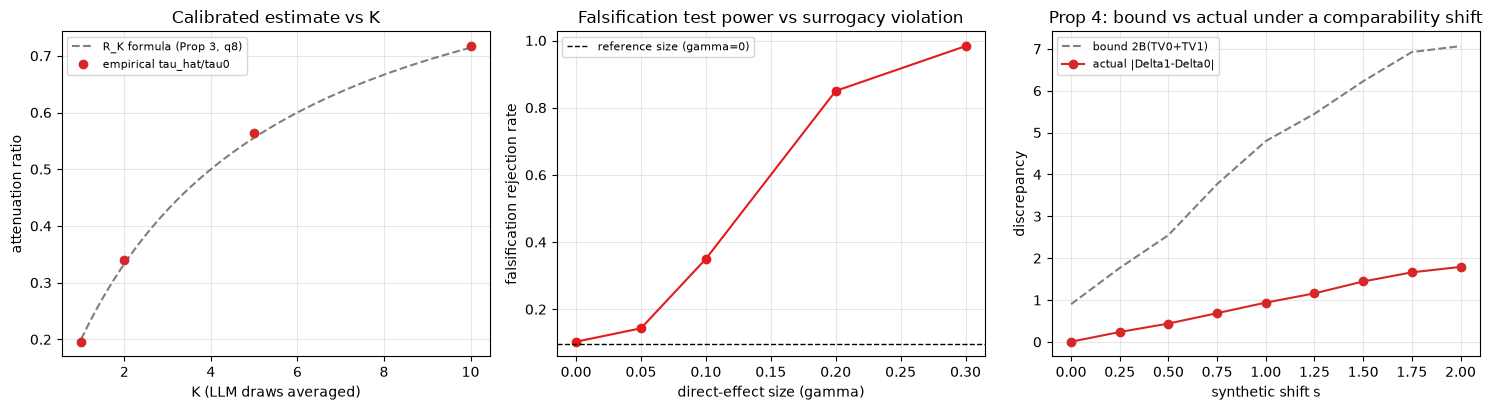

In [25]:
# Visualization only -- uses tau_ratio_by_K, R_K_formula_by_K, rejection_by_gamma, shifts5, actual_by_s, bound_by_s
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

ax = axes[0]
K_grid_fine = np.linspace(1, 10, 50)
R_K_curve = VAR_THETA_GIVEN_X_C / (VAR_THETA_GIVEN_X_C + SIGMA_EPS2_C / K_grid_fine)
ax.plot(K_grid_fine, R_K_curve, color=PALETTE["paper"], linestyle="--", label="R_K formula (Prop 3, q8)")
ax.plot(KS5, [tau_ratio_by_K[K] for K in KS5], "o", color=PALETTE["persson"], label="empirical tau_hat/tau0")
ax.set_xlabel("K (LLM draws averaged)"); ax.set_ylabel("attenuation ratio")
ax.set_title("Calibrated estimate vs K"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(GAMMAS5, [rejection_by_gamma[g] for g in GAMMAS5], "o-", color=PALETTE["bad"])
ax.axhline(expected_size_or, color="k", linestyle="--", linewidth=1, label="reference size (gamma=0)")
ax.set_xlabel("direct-effect size (gamma)"); ax.set_ylabel("falsification rejection rate")
ax.set_title("Falsification test power vs surrogacy violation"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(shifts5, bound_by_s, "--", color=PALETTE["paper"], label="bound 2B(TV0+TV1)")
ax.plot(shifts5, actual_by_s, "o-", color=PALETTE["persson"], label="actual |Delta1-Delta0|")
ax.set_xlabel("synthetic shift s"); ax.set_ylabel("discrepancy")
ax.set_title("Prop 4: bound vs actual under a comparability shift"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 6. Closing: three roles, three guarantees, and the gaps between them

**The three roles, restated with their actual guarantee (re-read q1, q12):**
- **Screen (Persson et al.):** *"Asymptotic Consistency: Plug-in estimator τ̂_K →^p τ"* (q1) —
  identification (Thm 3.1) + consistency only. **No coverage guarantee, no anytime-validity.** Use it
  to rank many candidate experiments cheaply; never to declare a launch decision on its own.
- **Measure (Lindon et al.):** *"P_P[δ ∈ C_n^α for all n ∈ ℕ] ≥ 1 − α"* (q1) — exact under the Gaussian
  linear model (Section 4), asymptotic under heteroskedastic/regression-adjusted forms (Sections 5–6).
  Use it to monitor a live A/B or onboarding-funnel test continuously without inflating false positives.
- **Iterate (Liang & Bojinov, MAD):** *"∃ (τ̄̂_t ± V_t*) with P(∀t, τ̄_t ∈ C_t) ≥ 1−α such that
  V̂_t/V_t* →^a.s. 1"* (q1), design-based. Use it to reallocate traffic toward the better-looking arm
  while still getting a valid confidence sequence on the ATE.

**Explicit gaps the sources do not close (q12; cross-paper rule 2 and 4), quoted, not inferred:**
1. **No combined covariate-adjusted MAD estimator:** *"No source in your notebook defines or proves a
   combined estimator that incorporates covariate regression adjustment into the Mixture Adaptive
   Design (MAD), nor do they provide an anytime-valid regression confidence sequence under adaptive
   assignment"* (q12). We did not build one.
2. **LLM predictions as covariates:** *"Neither paper evaluates using an LLM to generate a
   pre-experiment prediction score m_i(X)... Persson et al. model Y* strictly as a post-treatment
   outcome surrogate"* (q12). We never fed an LLM score into Section 3's regression as a
   variance-reduction covariate.
3. **No guarantee for LLM screen → MAD composition:** *"No source states or proves a formal guarantee
   for a two-stage pipeline where an LLM screens out arms prior to a MAD trial"* (q12); Persson et
   al.'s own falsification test is *"necessary but not sufficient and can fail on novel treatment
   arms"* (q12).
4. **No multi-experiment error control:** *"Neither paper states guarantees for controlling
   family-wise error rates (FWER) across multiple separate A/B tests run across different product
   features over time"* (q12) — running many sequential tests side by side (Sections 1–4's tools,
   repeated weekly) is not itself covered by any time-uniform guarantee across experiments.
5. **Non-stationarity breaks different things differently:** MAD's design-based CS *"remains
   asymptotically valid and tracks time-varying ATEs (including sign flips)"* (q12, q6); but *"Lindon
   et al. assume stationary/i.i.d. residual distributions"* (q12) and Persson et al.'s comparability
   assumption degrades under *"temporal shifts between early calibration data (P=0) and late deployment
   (P=1)... inflating total variation distance"* (q12) — exactly what Section 5(e) demonstrated
   numerically with the synthetic shift.

**Hand-off:** Notebook 2 builds a synthetic SaaS funnel (signup → activation → retention events) and
audits a founder's *current* peeking practice against it. Notebook 3 applies the three tools built here
— screen with a calibrated LLM estimate, measure with the regression-adjusted t-CS, iterate with MAD —
to that funnel, and is explicit about which of today's guarantees does and does not extend to the
applied pipeline.
